In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Basic imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import scipy as sp
from matplotlib import cm
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.collections import PolyCollection
import warnings
import re
from __future__ import annotations
from typing import Any, Dict, Mapping, Tuple
import numpy.typing as npt
sys.path.append('/home/xulu/code/MetaLearningDynamics')
from xulu_load_files import find_specific_sessions
warnings.filterwarnings("ignore")

In [3]:
# Import additional plotting and numerical functions used in analyses
from sys import stdout
from pylab import *                          
import statsmodels.api as sm
from statsmodels.genmod.families import Gaussian
from statsmodels.genmod.families.links import log
from statsmodels.tools.sm_exceptions import PerfectSeparationError
from scipy.stats import ranksums
from scipy.stats import wilcoxon
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF
import glob
from scipy.stats import ttest_1samp
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon
import statsmodels.formula.api as smf

# Perform K-fold cross validation.
from sklearn.model_selection import KFold
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import mean_squared_error, r2_score

# Regression packages
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler

In [4]:
fig_dir = '/stelmo/xulu/plots/'
results_dir = '/home/xulu/code/results/'


In [5]:
def convert_pos_and_time_to_indicators(data,num_bins_all_segs):
    ###### num_bins_all_segs is an array sotring number of bins for each leaf segment and during pauses: start leaf, end leaf, outcome period
    
    # Arrange the segment ids and head direction into a numpy array of position indicators
    pos_mat = np.zeros((data.shape[0],6*num_bins_all_segs.sum())) # Hard-coded "6" for the stem-leaf/6-arm maze
    column_names = np.empty((0,1))
    for i in range(6): # Currently hard-coded for the stem-leaf/6-arm maze
        seg_counter = 1
        for j in np.arange(num_bins_all_segs[0]-1,-1,-1): # Start leaf
            bool_ind = np.logical_and(np.array(data['track_segment_id'],dtype='object')==i+10*j,np.array(data['lin_velocity'],dtype='object')<0)
            pos_mat[bool_ind,num_bins_all_segs.sum()*i+seg_counter-1]=1
            column_names = np.vstack((column_names,f"leaf {i+1}-{seg_counter}"))
            seg_counter = seg_counter+1
        for j in range(num_bins_all_segs[1]): # End leaf
            bool_ind = np.logical_and(np.array(data['track_segment_id'],dtype='object')==i+10*j,np.array(data['lin_velocity'],dtype='object')>0)            
            pos_mat[bool_ind,num_bins_all_segs.sum()*i+seg_counter-1]=1
            column_names = np.vstack((column_names,f"leaf {i+1}-{seg_counter}"))
            seg_counter = seg_counter+1
        if num_bins_all_segs.shape[0] == 3:
            for j in np.arange(num_bins_all_segs[1],num_bins_all_segs[1]+num_bins_all_segs[2]): # Pause time
                bool_ind = np.logical_and(np.array(data['track_segment_id'],dtype='object')==i+10*j,np.array(data['lin_velocity'],dtype='object')==0)
                pos_mat[bool_ind,num_bins_all_segs.sum()*i+seg_counter-1]=1
                column_names = np.vstack((column_names,f"leaf {i+1}-{seg_counter}"))
                seg_counter = seg_counter+1
            
    column_names = column_names.flatten()
    pos_ind_df = pd.DataFrame(pos_mat, columns=column_names,index=data.index[:])
    return pos_ind_df

In [6]:
def create_turn_indicators_from_pos_and_time_indicators(pos_indicator,num_bins_per_seg,start_bin):
    # Position indicators (named 'turn_indicator') that only depends on left vs right turns but not specific starting leaves
    left_turn = (pos_indicator.filter(regex = f'-{start_bin}$').iloc[:,[0,2,4]]).sum(axis=1)
    right_turn = (pos_indicator.filter(regex = f'-{start_bin}$').iloc[:,[1,3,5]]).sum(axis=1)
    for i in np.arange(start_bin+1,start_bin+num_bins_per_seg[0]):
        left_turn = pd.concat([left_turn,(pos_indicator.filter(regex = f'-{i}$').iloc[:,[0,2,4]]).sum(axis=1)],axis=1)
        right_turn = pd.concat([right_turn,(pos_indicator.filter(regex = f'-{i}$').iloc[:,[1,3,5]]).sum(axis=1)],axis=1)   
    for i in np.arange(num_bins_per_seg[0]+1,num_bins_per_seg.sum()+1):
        left_turn = pd.concat([left_turn,(pos_indicator.filter(regex = f'-{i}$').iloc[:,[1,3,5]]).sum(axis=1)],axis=1)
        right_turn = pd.concat([right_turn,(pos_indicator.filter(regex = f'-{i}$').iloc[:,[0,2,4]]).sum(axis=1)],axis=1)   
    bin_sequence = np.arange(start_bin,start_bin+num_bins_per_seg.sum())
    left_turn.columns = [f'left turn {i}' for i in bin_sequence]
    right_turn.columns = [f'right turn {i}' for i in bin_sequence]
    return pd.concat([left_turn,right_turn],axis=1)

In [7]:
def create_patch_indicators_from_pos_and_time_indicators(pos_indicator,num_bins_per_seg,start_bin):
    ########## TODO: use a loop to create indicators for the 3 stems rather than repeating the same code three times
    patchA_indicator = pos_indicator.filter(like='leaf 1-1').join(pos_indicator.filter(like='leaf 2-1')).sum(axis=1)
    patchB_indicator = pos_indicator.filter(like='leaf 3-1').join(pos_indicator.filter(like='leaf 4-1')).sum(axis=1)
    patchC_indicator = pos_indicator.filter(like='leaf 5-1').join(pos_indicator.filter(like='leaf 6-1')).sum(axis=1)
    for i in np.arange(start_bin+1,start_bin+num_bins_per_seg.sum()):
        patchA_indicator = pd.concat([patchA_indicator,pos_indicator.filter(like=f'leaf 1-{i}').join(pos_indicator.filter(like=f'leaf 2-{i}')).sum(axis=1)],axis=1)
        patchB_indicator = pd.concat([patchB_indicator,pos_indicator.filter(like=f'leaf 3-{i}').join(pos_indicator.filter(like=f'leaf 4-{i}')).sum(axis=1)],axis=1)
        patchC_indicator = pd.concat([patchC_indicator,pos_indicator.filter(like=f'leaf 5-{i}').join(pos_indicator.filter(like=f'leaf 6-{i}')).sum(axis=1)],axis=1)
    bin_sequence = np.arange(start_bin,start_bin+num_bins_per_seg.sum())
    patchA_indicator.columns = [f'stemA {i}' for i in bin_sequence]
    patchB_indicator.columns = [f'stemB {i}' for i in bin_sequence]
    patchC_indicator.columns = [f'stemC {i}' for i in bin_sequence]
    return pd.concat([patchA_indicator,patchB_indicator,patchC_indicator],axis=1)

In [8]:
def create_progress_indicators_from_turn_indicators(turn_indicator,bin_sequence):
    # Progression indicators that only depend on the fraction of a trial that the rat has completed
    progress_indicator = turn_indicator.filter(regex = f'turn {bin_sequence[0]}$').sum(axis=1)
    for i in bin_sequence[1:]:
        progress_indicator = pd.concat([progress_indicator,turn_indicator.filter(regex = f'turn {i}').sum(axis=1)],axis=1)
    progress_indicator.columns = [f'bin {i}' for i in bin_sequence]
    return progress_indicator

In [9]:
def reorganize_df_columns(df,leaf_grps):
    df_reorg = pd.DataFrame()                    
        ##### Bins 8,7,6,5,1,2,3,4 for each traversal type            
    for i in range(leaf_grps.shape[0]):
            for k in np.linspace(int(df.shape[1]/6),int(df.shape[1]/6)/2+1,int(df.shape[1]/6/2),dtype=int):
                df_reorg = pd.concat([df_reorg,df[f'leaf {leaf_grps[i][0]}-{k}']],axis=1)
            for k in np.linspace(1,int(df.shape[1]/6)/2,int(df.shape[1]/6/2),dtype=int):
                df_reorg = pd.concat([df_reorg,df[f'leaf {leaf_grps[i][1]}-{k}']],axis=1)

    return df_reorg

In [10]:
def group_data_per_key(data):
    vals = np.array([np.asarray(v).ravel()[[0,-1]] for v in data.values()])  # shape (n, 2)
    
    g1 = vals[:, 0].astype(float)
    g2 = vals[:, 1].astype(float)
    
    g1 = g1[~np.isnan(g1)]
    g2 = g2[~np.isnan(g2)]

    return g1, g2

In [11]:
def plot_mean_with_sem(array_list,array_names,y_label,fig_name,save_fig,colors,mean_only=False,line_styles=None,*args, **kwargs):
    
    fig, ax = plt.subplots(1,1,figsize=(5,3))
    
    for i in range(len(array_list)):
        mean = np.mean(array_list[i],axis=0)
        if not mean_only:
            sem = stats.sem(array_list[i],axis=0)
        if line_styles==None:
            ax.plot(range(int(mean.shape[0])),mean,color=colors[i,:])
        else:
            ax.plot(range(int(mean.shape[0])),mean,color=colors[i,:],linestyle=line_styles[i])  
        if not mean_only:
            ax.errorbar(range(int(mean.shape[0])),mean,yerr=sem,color=colors[i,:],fmt='o',capsize=3.6)
        
    ax.axvline(x=3.5,color='k',label='axvline - full height',ls='--')

    if len(kwargs) != 0:
        ax.set_ylim(kwargs['ylim'])
        
    # ax.legend(array_names,bbox_to_anchor=(1,1))
    # ax.legend(array_names, loc="upper left")
    ax.legend(array_names, loc="upper right")
    
    ax.set_xticks(range(8))
    ax.set_xticklabels(["start leaf","","","","","","","end leaf"])
    ax.set_ylabel(y_label);
    # plt.tight_layout()
    sns.despine(trim=True,left=False)
    if save_fig == 1:
        plt.savefig(fig_dir+fig_name)

In [12]:
def bootstrap_mean_ci(x, alpha=0.05, n_boot=10000, seed=0):
    x = np.asarray(x); x = x[~np.isnan(x)]
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    m = x.mean()
    lo, hi = np.quantile(boots, [alpha/2, 1 - alpha/2])
    return m, lo, hi

In [13]:
# LASSO regresion with CV.
def regularized_regression_CV(X,y,n_repeats,reg_type):
    r2_test = np.empty(shape=(0,1), dtype=np.int64)
    mse_test = np.empty(shape=(0,1), dtype=np.int64)
    coeff = np.empty(shape=(0,X.shape[1]), dtype=np.int64)
    for i in np.arange(0,n_repeats,1):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i)
        if reg_type == "LASSO":
            reg = LassoCV(cv=5, max_iter=10000, random_state=0, n_alphas=200).fit(X_train, y_train)
            model_best = Lasso(alpha=reg.alpha_)

        model_best.fit(X_train,y_train)        
        r2_test = np.vstack((r2_test,round(model_best.score(X_test,y_test), 2)))
        mse_test = np.vstack((mse_test,mean_squared_error(y_test, model_best.predict(X_test))))
        coeff = np.vstack((coeff,model_best.coef_))
        if (i+1) % 20 == 0:
            print(f'finished {i+1} repeats')
    return mse_test.flatten(),r2_test.flatten(),coeff

In [15]:
def get_neural_behav_data_for_regression(file,selected_trials,selected_neurons,no_dep=False,add_leaf=False,use_selected_sessions=False,use_updated_value=False,incl_pause_time=False,smooth_neural=0):
    bins_per_seg = 4 # Set as constant for now, might move it to function input when needed in the future.
    # Position indicators that depends on specific leaves + left vs. right turns.
    if incl_pause_time:
        bins_all_segs = np.array([bins_per_seg,bins_per_seg,3]) # num of bins of start leaf, end leaf, pause time
    else:
        bins_all_segs = np.array([bins_per_seg,bins_per_seg]) # num of bins of start leaf, end leaf

    data_dir = '/home/xulu/code/preliminary_data/'+file+'_ValueDecision/'
        
    if smooth_neural == 1:
        smooth_type = "GaussianSmooth"
    else:
        smooth_type = "NoSmooth"
    # Load big data frame (data_df):
    if incl_pause_time:
        data_df_switch_dir = data_dir+file+f"_data_df_{smooth_type}_mPFC_{int(bins_per_seg*2+3)}bins_WithOutcome+RewardHist+ExpVal+PatchVal+PastVal+ValueDiff+ValueDiffMax+AltValue+StemStayP+SwitchTrialID+HeadDir+HeadAngle+Velocity.pkl"    
    else:
        data_df_switch_dir = data_dir+file+f"_data_df_{smooth_type}_mPFC_{int(bins_per_seg*2)}bins_WithOutcome+RewardHist+ExpVal+PatchVal+PastVal+ValueDiff+ValueDiffMax+AltValue+StemStayP+SwitchTrialID+HeadDir+HeadAngle+Velocity.pkl"    
    if add_leaf:
        data_df_switch_dir = data_df_switch_dir[:-4]+'_addleaf.pkl'
    if no_dep:
        data_df_switch_dir = data_df_switch_dir[:-4]+'_nodep.pkl'
    if os.path.exists(data_df_switch_dir):
        print(f'loading {data_df_switch_dir}')
        data_df = pd.read_pickle(data_df_switch_dir)
    else:
        print('dataframe doesn not exist yet, please use the StemLeaf_single_neuron_response notebook to create it')
    # Add a column indicating trial num after a stem switch
    pokes_after_switch = data_df['trial id before switch'] + data_df['pokes before switch']
    pokes_after_switch[data_df['trial id before switch']==0] = 0
    data_df = pd.concat((data_df,pd.DataFrame({'trial id after switch':pokes_after_switch})),axis=1)    
    data_df.columns = data_df.columns.str.replace(" ", "_", regex=False) # replace all spaces in the column names of data_df by underscore
    # For last few trials without a switch, we assign the correct trial_id_after_switch rather than 0.
    for i in data_df.session.unique():
        mask = (data_df['pokes_before_switch'] == 100) & (data_df['session'] == i)
        new_values = np.repeat(np.arange(1,int(mask.sum()/bins_all_segs.sum())+1,1), bins_all_segs.sum())
        data_df.loc[mask, 'trial_id_after_switch'] = new_values
    ###### Add a column indicating start stem. ######
    start_stem_array = np.empty((0,))
    for i in range(data_df.shape[0]):
     if data_df.start_leaf.iloc[i] == 1 or data_df.start_leaf.iloc[i] == 2:
         stem = 1
     if data_df.start_leaf.iloc[i] == 3 or data_df.start_leaf.iloc[i] == 4:
         stem = 2
     if data_df.start_leaf.iloc[i] == 5 or data_df.start_leaf.iloc[i] == 6:
         stem = 3
     start_stem_array = np.concatenate((start_stem_array,[stem]))
    if not 'start_stem' in data_df.columns:
        data_df = pd.concat((data_df,pd.DataFrame({'start_stem':start_stem_array},index=data_df.index)),axis=1)
    
    # Load other data (behav only, and spike times only) in case needed.
    behav_data_all = pd.read_pickle(data_dir+file+"_behav_data_all.pkl")
    if add_leaf:
        behav_data_all = pd.read_pickle(data_dir+file+"_behav_data_all_addleaf.pkl")
    if no_dep:
        behav_data_all = pd.read_pickle(data_dir+file+"_behav_data_all_nodep.pkl")
    spikeT = np.load(data_dir+file+"_spike_time_all_curated.npy",allow_pickle=True)
    if os.path.exists(results_dir+file+"_curated_active_neuron_index_0.5thres_everysesh.npy"):
        active_neurons = np.load(results_dir+file+"_curated_active_neuron_index_0.5thres_everysesh.npy")
    else:
        active_neurons = np.load(results_dir+file+"_curated_active_neuron_index_0.5thres.npy",allow_pickle=True)
    print(f'There are {active_neurons.shape[0]} active neurons.')

    # Load value neuron indices if pre-computed.
    value_ind_dir = results_dir+file+"_curated_value+valdiff_neuron_index_8bins.npy"
    if os.path.exists(value_ind_dir):
        value_neurons = np.load(value_ind_dir,allow_pickle=True)
        print(f'There are {value_neurons.shape[0]} value neurons.')
        
    # First trial of some sessions might have the same poke-in and poke-out times (likely because experimenter started recording after rats had started running), and we need to exclude them
    # Drop all rows whose trial_id is in those bad trials with occupancy == 0:
    bad_trials = data_df.loc[data_df['occupancy'] == 0, 'trial_id'].unique()
    data_df = data_df[~data_df['trial_id'].isin(bad_trials)].copy()
    
    if incl_pause_time & use_updated_value:# Use the updated value difference estimate for pause times (i.e., the value difference max estimated for the next trial)
        condition = ((data_df['track_segment_id']/10).astype('int')) >=4
        data_df.loc[condition, 'value_difference_max'] = data_df.loc[condition, 'value_difference_next']
        # data_df = data_df.loc[data_df['value_difference_max'].notna()] # This could result in some trials only partially dropped (e.g. when only some of its value is nan)
        bad_trials = data_df.loc[data_df['value_difference_max'].isna(), 'trial_id'].unique()
        data_df = data_df[~data_df['trial_id'].isin(bad_trials)].copy()
            
    if selected_trials == "":
        data_df_selected = data_df # Use all trials
    if selected_trials == "_StayTrials":
        data_df_selected = data_df[data_df['stem_switch']==False]
         
    sess_selected = data_df_selected['session'].unique()
    if use_selected_sessions:
        sess_selected=find_specific_sessions(file,sess_orig=sess_selected)
    print(f'selected sessions {sess_selected}')
    data_df_selected = data_df_selected[data_df_selected['session'].isin(sess_selected)]
    
    print(f"There're {data_df_selected.shape[0]} datapoints for regression.")

    pos_indicator_df = convert_pos_and_time_to_indicators(data_df_selected,bins_all_segs)
    # Position indicators (named 'turn_indicator') that only depends on left vs right turns but not specific starting leaves
    first_bin = 1    
    turn_indicator_df = create_turn_indicators_from_pos_and_time_indicators(pos_indicator_df,bins_all_segs,first_bin)

    # Position indicators that depend on progression and stem/patch identity.
    patch_indicator_df = create_patch_indicators_from_pos_and_time_indicators(pos_indicator_df,bins_all_segs,first_bin)

    # Position indicators that only depends on trial progression
    prog_bin_sequence = np.arange(first_bin,first_bin+bins_all_segs.sum())
    progress_indicator_df = create_progress_indicators_from_turn_indicators(turn_indicator_df,prog_bin_sequence)
    
    # Get neural spikes data of value neurons.
    all_units = range(0,spikeT.shape[0])
    if selected_neurons == 'value_neurons':
        predictor_neurons = value_neurons # Choose neurons that will be used in the predictor
    if selected_neurons == 'active_neurons':
        predictor_neurons = active_neurons
    
    spikes_by_posbins = (data_df_selected.filter(regex='spike_train')).iloc[:,np.isin(all_units,predictor_neurons)]
    
    return sess_selected,data_df_selected,pos_indicator_df,turn_indicator_df,patch_indicator_df,progress_indicator_df,spikes_by_posbins,all_units,predictor_neurons


In [16]:
def get_mean_and_sem_per_group(file,y,bins_per_journey,bin_type,combine_bins=False):
    switch_ids = np.arange(-8,1,1)
    if np.isin(file,['peanut20201205','peanut20201206','peanut20201208','senor20201113','chimi20200305','chimi20200308']):
        switch_ids = np.arange(-6,1,1)
    if np.isin(file,['j1620210718','j1620210719']) & one_poke_trial:
        switch_ids = np.arange(-6,1,1)
    if np.isin(file,['senor20201121','peanut20201209','senor20201114','senor20201116','chimi20200311']):
        switch_ids = np.arange(-5,1,1)
    if not from_best_stem:
        switch_ids = np.arange(-4,1,1)
        if np.isin(file,['senor20201114','senor20201116']):
            switch_ids = np.arange(-3,1,1)
    if trial_alignment == 'trial_id_after_switch':
        switch_ids = (-switch_ids)[::-1]
    
    prog_bin_sequence = np.arange(1,1+bins_per_journey)
    if bin_type == 'prog':
        bin_names = np.array([f'bin {i}' for i in prog_bin_sequence])
    if bin_type == 'turn':
        bin_names = [f'left turn {i}' for i in prog_bin_sequence]+[f'right turn {i}' for i in prog_bin_sequence]
    if bin_type == 'patchprog':
        bin_names = [f'stemA {i}' for i in prog_bin_sequence]+[f'stemB {i}' for i in prog_bin_sequence]+[f'stemC {i}' for i in prog_bin_sequence]
    
    bin_names_plot = bin_names
    if combine_bins and bin_type != 'prog':
        bin_names_plot = np.array([f'bin {i}' for i in prog_bin_sequence])
    
    mean_allcond = np.zeros((switch_ids.shape[0],len(bin_names_plot)))
    sem_allcond = np.zeros((switch_ids.shape[0],len(bin_names_plot)))
        
    for i in range(switch_ids.shape[0]):
        mean = np.empty((0,))
        sem = np.empty((0,))
        if combine_bins:
            if bin_type == 'turn':
                for j in range(len(bin_names)//2):
                    mean = np.concatenate((mean,[np.nanmean(np.concatenate((y[bin_names[j]+f' trial {switch_ids[i]}'],\
                                                             y[bin_names[j+len(bin_names)//2]+f' trial {switch_ids[i]}'])))]))
                    sem =  np.concatenate((sem,[stats.sem(np.concatenate((y[bin_names[j]+f' trial {switch_ids[i]}'],\
                                                                      y[bin_names[j+len(bin_names)//2]+f' trial {switch_ids[i]}'])),nan_policy='omit')]))
            if bin_type == 'patchprog':
                for j in range(len(bin_names)//3):
                    mean = np.concatenate((mean,[np.nanmean(np.concatenate((y[bin_names[j]+f' trial {switch_ids[i]}'],\
                                                                 y[bin_names[j+len(bin_names)//3]+f' trial {switch_ids[i]}'],\
                                                                 y[bin_names[j+len(bin_names)//3*2]+f' trial {switch_ids[i]}'])))]))
                    sem =  np.concatenate((sem,[stats.sem(np.concatenate((y[bin_names[j]+f' trial {switch_ids[i]}'],\
                                                                          y[bin_names[j+len(bin_names)//3]+f' trial {switch_ids[i]}'],\
                                                                          y[bin_names[j+len(bin_names)//3*2]+f' trial {switch_ids[i]}'])),nan_policy='omit')]))
                
        else:
            for bin_name in bin_names_plot:
                mean = np.concatenate((mean,[np.nanmean((y[bin_name+f' trial {switch_ids[i]}']))]))
                sem =  np.concatenate((sem,[stats.sem(y[bin_name+f' trial {switch_ids[i]}'],nan_policy='omit')]))
        mean_allcond[i,:] = mean
        sem_allcond[i,:] = sem
    return mean_allcond,sem_allcond

In [17]:
# Specific params for loading behav/neural data.
selected_trials = ""
# selected_trials = "_StayTrials"

# neuron_str = 'value_neurons'
neuron_str = 'active_neurons'

## 1. Fit cross-validated LASSO with repeats

### 1.1 Model fitting

In [ ]:
# Test MSE for value prediction of each of 8 progression bins in each stem fit separately.
no_dep = False
add_leaf = True
save_results = True
subsample = False
incl_pause_time = True
normalize_DVs = False # No normalization if we want to compare across days.
# DV_types = ['value_difference_next']
# DV_types = ['value_difference_max']
DV_types = ['value_difference_max','value_difference_next']

# All days:
# file_names = ['j1620210714','j1620210715','j1620210716','j1620210717','j1620210718','j1620210719',\
#               'wilbur20210404','wilbur20210406','wilbur20210407','wilbur20210408','wilbur20210409',\
#               'senor20201109','senor20201111','senor20201114','senor20201116','senor20201121',\
#               'peanut20201203','peanut20201205','peanut20201206','peanut20201208','peanut20201209',\
#               'wilbur20210405','j1620210715']

# Early and late days:
file_names = ['j1620210714','j1620210718','j1620210719',\
              'wilbur20210404','wilbur20210408','wilbur20210409','wilbur20210410',\
              'senor20201109','senor20201113','senor20201114','senor20201116','senor20201121',\
              'peanut20201203','peanut20201208','peanut20201209']

behav_model = 'betalik'
method = 'LASSO'
# bin_types = ['prog']
bin_types = ['prog','turn','patchprog','journey']

sample_str = ""
repeats = 20 # repeat times of 5-fold CV.

for file_name in file_names:
    # Determine whether we exclude certain sessions from analysis. TODO: make an automated criteria based on behaviora performance or something.
    if np.isin(file_name,['j1620210719','wilbur20210406','wilbur20210408','wilbur20210409',\
                          'senor20201113','senor20201114','senor20201116','senor20201121',\
                          'peanut20201205','peanut20201206','peanut20201208','peanut20201209','chimi20200311']):
        use_selected_sessions = True
    else:
        use_selected_sessions = False
    
    print(f"\nfitting {file_name}")
    sess_selected,data_df_selected,pos_indicator_df,turn_indicator_df,patch_indicator_df,progress_indicator_df,spikes_by_posbins,all_units,predictor_neurons = \
    get_neural_behav_data_for_regression(file=file_name,selected_trials=selected_trials,no_dep=no_dep,add_leaf=add_leaf,\
                                         incl_pause_time=incl_pause_time,selected_neurons=neuron_str,use_selected_sessions=use_selected_sessions)

    if normalize_DVs:
        for DV_type in DV_types:
            data_df_selected[DV_type] = (data_df_selected[DV_type]-data_df_selected[DV_type].mean())/data_df_selected[DV_type].std()

    data_df_selected_copy = data_df_selected.copy()
    spikes_by_posbins_copy = spikes_by_posbins.copy()
    for bin_type in bin_types:
        for DV_type in DV_types:
            data_df_selected = data_df_selected_copy.copy()
            spikes_by_posbins = spikes_by_posbins_copy.copy()
            mse = dict()
            r2 = dict()
            coeff = dict()
            if DV_type == 'value_difference_next':
                data_df_selected = data_df_selected.loc[data_df_selected['value_difference_next'].notna()]
                spikes_by_posbins = (data_df_selected.filter(regex='spike_train')).iloc[:,np.isin(all_units,predictor_neurons)] # Re-aquire spikes data as data_df_selected may be different now after removing nan trials
            
            trial_ids = data_df_selected['trial_id'].unique().astype('int64')
            if bin_type == 'prog':
                indicator_df = progress_indicator_df
                sampled_trials = np.random.choice(trial_ids,int(trial_ids.shape[0]/6),replace=False)
            if bin_type == 'turn':
                indicator_df = turn_indicator_df
                sampled_trials = np.random.choice(trial_ids,int(trial_ids.shape[0]/3),replace=False)
            if bin_type == 'patchprog':
                indicator_df = patch_indicator_df
                sampled_trials = np.random.choice(trial_ids,int(trial_ids.shape[0]/2),replace=False)
            if bin_type == 'journey':
                indicator_df = pos_indicator_df   

            if subsample:                
                indicator_df = indicator_df[data_df_selected['trial_id'].astype('int64').isin(sampled_trials)]
                spikes_by_posbins = spikes_by_posbins[data_df_selected['trial_id'].astype('int64').isin(sampled_trials)]
                data_df_selected = data_df_selected[data_df_selected['trial_id'].astype('int64').isin(sampled_trials)]   
                sample_str = "_subsampled2"
                print("Using subsampled trials")
            
            for bin_name in indicator_df.columns:
                data_index = indicator_df[bin_name]==1
                X_fr = (spikes_by_posbins.div(data_df_selected['occupancy'],axis=0))[data_index]
                y_val = (data_df_selected[DV_type])[data_index]
                if method == 'LASSO':
                    mse[bin_name],r2[bin_name],coeff[bin_name] = regularized_regression_CV(X_fr,y_val,repeats,"LASSO")
                if method == 'LASSO_shuffle':    
                    X_fr = X_fr.sample(frac=1).set_index(X_fr.index)
                    mse[bin_name],r2[bin_name],coeff[bin_name] = regularized_regression_CV(X_fr,y_val,repeats,"LASSO")
    
            print(f"fitted {bin_type}, {DV_type}:")
            for bin_name in indicator_df.columns:
                print(f'{bin_name} r2: {np.mean(r2[bin_name])}')
            if DV_type == 'expected_value':
                DV_string = 'expval'
            if DV_type == 'past_value':
                DV_string = 'pastval'
            if DV_type == 'value_difference_max':
                DV_string = 'valdiffmax'
            if DV_type == 'value_difference_next':
                DV_string = 'valdiffmaxnext'

            if save_results:
                results_file = results_dir+f"{behav_model}_value/"+file_name+f"_{method}_value_prediction_over_{indicator_df.shape[1]}{bin_type}bins_{DV_string}{selected_trials}{sample_str}_{neuron_str}.npz"
                if use_selected_sessions:
                    results_file = results_file[:-4] + f"_r{''.join(str(int(n)) for n in sess_selected)}.npz"
                if no_dep:
                    results_file = results_file[:-4]+'_nodep.npz'
                if add_leaf:
                    results_file = results_file[:-4]+'_addleaf.npz'
                np.savez(results_file,mse=mse,r2=r2,coeff=coeff,allow_pickle=True)



fitting j1620210714
loading /home/xulu/code/preliminary_data/j1620210714_ValueDecision/j1620210714_data_df_NoSmooth_mPFC_11bins_WithOutcome+RewardHist+ExpVal+PatchVal+PastVal+ValueDiff+ValueDiffMax+AltValue+StemStayP+SwitchTrialID+HeadDir+HeadAngle+Velocity_addleaf.pkl
There are 59 active neurons.
There are 46 value neurons.
There are 42 decision neurons.
selected sessions [1. 2. 3. 4. 5. 6.]
There're 19723 datapoints for regression.
finished 20 repeats
finished 20 repeats
finished 20 repeats
finished 20 repeats
finished 20 repeats
finished 20 repeats
finished 20 repeats
finished 20 repeats
finished 20 repeats
finished 20 repeats
finished 20 repeats
fitted prog, value_difference_max:
bin 1 r2: 0.516
bin 2 r2: 0.46099999999999997
bin 3 r2: 0.43549999999999994
bin 4 r2: 0.399
bin 5 r2: 0.30300000000000005
bin 6 r2: 0.3705
bin 7 r2: 0.391
bin 8 r2: 0.47050000000000003
bin 9 r2: 0.378
bin 10 r2: 0.28650000000000003
bin 11 r2: 0.2495
finished 20 repeats
finished 20 repeats
finished 20 repe

### 1.2 Print saved r2 for different models

In [167]:
no_dep = False
add_leaf = True

######## Define parameters for loading results of interest. #######
file_name = 'wilbur20210409'
behav_model = 'betalik'
value_type = 'value_difference_max'
DV_string = 'valdiffmax'
# bin_type = '8prog'
bin_type = '11prog'
# bin_type = '16turn'
# bin_type = '22turn'
# bin_type = '48journey'
# neuron_str = 'value_neurons'
neuron_str = 'active_neurons'
sample_str = ""

# Determine whether we exclude certain sessions from analysis. TODO: make an automated criteria based on behaviora performance or something.
if np.isin(file_name,['j1620210719','wilbur20210406','wilbur20210408','wilbur20210409',\
                      'senor20201113','senor20201114','senor20201116','senor20201121',\
                      'peanut20201205','peanut20201206','peanut20201208','peanut20201209','chimi20200311']):
    use_selected_sessions = True
else:
    use_selected_sessions = False
sess_all = np.arange(1,6,1)
if use_selected_sessions:
    sess = find_specific_sessions(file_name,sess_orig=sess_all)

######## Load results #########
print(value_type)
print(behav_model)

results_file = results_dir+f"{behav_model}_value/"+file_name+f"_LASSO_value_prediction_over_{bin_type}bins_{DV_string}{selected_trials}{sample_str}_{neuron_str}.npz"
if use_selected_sessions:
    results_file = results_file[:-4] + f"_r{''.join(str(int(n)) for n in sess)}.npz"
if no_dep:
    results_file = results_file[:-4] + "_nodep.npz"
if add_leaf:
    results_file = results_file[:-4] + "_addleaf.npz"
results = np.load(results_file,allow_pickle=True)
print(f'loaded {results_file}')
r2 = results.f.r2.item()

######## Print results #########
if bin_type == '11prog':
    bin_seq = np.arange(1,12)
else:
    bin_seq = np.arange(1,9)

if bin_type == '11prog' or bin_type == '8prog':
    bin_names = [f'bin {i}' for i in bin_seq]
if bin_type == '22turn' or bin_type == '16turn':
    bin_names = np.concatenate(([f'left turn {i}' for i in bin_seq],[f'right turn {i}' for i in bin_seq]))
if bin_type == 'patchprog':
    bin_names = np.concatenate(([f'stemA {i}' for i in bin_sequence],[f'stemB {i}' for i in bin_sequence],[f'stemC {i}' for i in bin_sequence]))
if bin_type == 'journey':
    bin_names = pos_indicator_df.columns()
    
print(f'{file_name} decoding perforamance:')
for bin_name in bin_names:
    print(f'{bin_name} r2: {np.mean(r2[bin_name])}')


value_difference_max
betalik
loaded /home/xulu/code/preliminary_results/betalik_value/wilbur20210409_LASSO_value_prediction_over_11progbins_valdiffmax_active_neurons_r1234_addleaf.npz
wilbur20210409 decoding perforamance:
bin 1 r2: 0.4334999999999999
bin 2 r2: 0.40499999999999997
bin 3 r2: 0.4875000000000001
bin 4 r2: 0.477
bin 5 r2: 0.45099999999999996
bin 6 r2: 0.4050000000000001
bin 7 r2: 0.4125
bin 8 r2: 0.3815
bin 9 r2: 0.356
bin 10 r2: 0.275
bin 11 r2: 0.199


### 1.3 Load model r2 for statistical tests and plotting

In [18]:
# Melt arrays to long-form DataFrame
def melt_array(arr, label):
    df = pd.DataFrame(arr, columns=group_labels)
    df['Day'] = np.arange(len(arr))
    df_melted = df.melt(id_vars='Day', var_name='Bin', value_name='Var explained')
    df_melted['Condition'] = label
    return df_melted

In [244]:
behav_model = 'betalik'
method = 'LASSO'
# method = 'LASSO_shuffle'
# value_strs = ['valdiffmax']
value_strs = ['valdiffmax','valdiffmaxnext']

all_decay_dates = ['j1620210714','j1620210715','j1620210716','j1620210717','j1620210718','j1620210719',\
              'wilbur20210404','wilbur20210405','wilbur20210406','wilbur20210407','wilbur20210408','wilbur20210409','wilbur20210410',\
              'senor20201109','senor20201111','senor20201113','senor20201114','senor20201116','senor20201121',\
              'peanut20201203','peanut20201205','peanut20201206','peanut20201208','peanut20201209']

# all_decay_dates = ['j1620210714','wilbur20210404','senor20201109','peanut20201203'] # All early days
 
# all_decay_dates = ['j1620210717','j1620210718','j1620210719',\
#               'wilbur20210408','wilbur20210409','wilbur20210410',\
#               'senor20201113','senor20201114','senor20201116',\
#               'peanut20201208','peanut20201209'] # All late days

plot_files = all_decay_dates
# plot_files = all_stable_dates

# plot_bin_type = '48journeybins'
# plot_bin_type = "24patchprogbins"
# plot_bin_type = '16turnbins'
# plot_bin_type = '8progbins'
plot_bin_type = '11progbins'

selected_trials = ''
# selected_trials = '_StayTrials'

predictor_neuron_str = '_active_neurons'
# predictor_neuron_str = '_value_neurons'

sample_strs = ['']
# sample_strs = ['_subsampled1','_subsampled2','_subsampled3']

if method == "LASSO":
    # r2_expected_list = []
    # r2_past_list = []
    r2_valdiff_list = []
    r2_valdiffnext_list = []
if method == "LASSO_shuffle":
    # r2_expected_ctrl_list = []
    # r2_past_ctrl_list = []
    r2_valdiff_ctrl_list = []    

for sample_str in sample_strs:
    for file_name in plot_files:  
        if np.isin(file_name,['j1620210719','wilbur20210406','wilbur20210408','wilbur20210409',\
                              'senor20201113','senor20201114','senor20201116','senor20201121',\
                              'peanut20201205','peanut20201206','peanut20201208','peanut20201209','chimi20200311']):
            use_selected_sessions = True
        else:
            use_selected_sessions = False
        sess_all = np.arange(1,6,1)
        if use_selected_sessions:
            sess = find_specific_sessions(file_name,sess_orig=sess_all)
    
        for value_string in value_strs:             
            results_file = results_dir+f"{behav_model}_value/"+file_name+f"_{method}_value_prediction_over_{plot_bin_type}_{value_string}{sample_str}{predictor_neuron_str}{selected_trials}.npz"            
            if use_selected_sessions:
                results_file = results_file[:-4] + f"_r{''.join(str(int(n)) for n in sess)}.npz"
            print(f'loaded {results_file}')
            a = np.load(results_file,allow_pickle=True)
            
            if value_string == 'expval':           
                r2_expected = a.f.r2.item()
            if value_string == 'pastval':
                r2_past = a.f.r2.item()
            if value_string == 'valdiffmax':
                r2_valdiff = a.f.r2.item()       
            if value_string == 'valdiffmaxnext':
                r2_valdiffnext = a.f.r2.item()
                
        if method == "LASSO_shuffle":
            # for value in r2_expected.values():
            #     r2_expected_ctrl_list.append(np.mean(value))
            # for value in r2_past.values():
            #     r2_past_ctrl_list.append(np.mean(value))
            for value in r2_valdiff.values():
                r2_valdiff_ctrl_list.append(np.mean(value))         
        if method == "LASSO":
            # for value in r2_expected.values():
            #     r2_expected_list.append(mean(value))
            # for value in r2_past.values():
            #     r2_past_list.append(mean(value))
            for value in r2_valdiff.values():
                r2_valdiff_list.append(np.mean(value))
            if 'r2_valdiffnext' in locals():
                for value in r2_valdiffnext.values():
                    r2_valdiffnext_list.append(np.mean(value)) 
            

loaded /home/xulu/code/preliminary_results/betalik_value/j1620210714_LASSO_value_prediction_over_11progbins_valdiffmax_active_neurons.npz
loaded /home/xulu/code/preliminary_results/betalik_value/j1620210714_LASSO_value_prediction_over_11progbins_valdiffmaxnext_active_neurons.npz
loaded /home/xulu/code/preliminary_results/betalik_value/j1620210715_LASSO_value_prediction_over_11progbins_valdiffmax_active_neurons.npz
loaded /home/xulu/code/preliminary_results/betalik_value/j1620210715_LASSO_value_prediction_over_11progbins_valdiffmaxnext_active_neurons.npz
loaded /home/xulu/code/preliminary_results/betalik_value/j1620210716_LASSO_value_prediction_over_11progbins_valdiffmax_active_neurons.npz
loaded /home/xulu/code/preliminary_results/betalik_value/j1620210716_LASSO_value_prediction_over_11progbins_valdiffmaxnext_active_neurons.npz
loaded /home/xulu/code/preliminary_results/betalik_value/j1620210717_LASSO_value_prediction_over_11progbins_valdiffmax_active_neurons.npz
loaded /home/xulu/code

In [245]:
# Reorganize results as N_datasets X n_pos_bins arrays.
incl_pause_time = True
n_bins_per_journey = 8
if incl_pause_time:
    n_bins_per_journey = 11
# r2_expected_array = np.array(r2_expected_list).reshape(int(len(r2_expected_list)/n_bins_per_journey),n_bins_per_journey)
# r2_past_array = np.array(r2_past_list).reshape(int(len(r2_past_list)/n_bins_per_journey),n_bins_per_journey)
r2_valdiff_array = np.array(r2_valdiff_list).reshape(int(len(r2_valdiff_list)/n_bins_per_journey),n_bins_per_journey)

if 'r2_valdiff_ctrl_list' in locals():
    r2_valdiff_ctrl_array = np.array(r2_valdiff_ctrl_list).reshape(int(len(r2_valdiff_ctrl_list)/n_bins_per_journey),n_bins_per_journey)
if 'r2_valdiffnext_list' in locals():
    r2_valdiffnext_array = np.array(r2_valdiffnext_list).reshape(int(len(r2_valdiffnext_list)/n_bins_per_journey),n_bins_per_journey)

if plot_bin_type == "8progbins" or plot_bin_type == "11progbins":
    r2_valdiff_prog_array=r2_valdiff_array
    if '_subsampled1' in sample_strs: # Take the average of the repeated sampled results.
        r2_valdiff_prog_array = np.array([r2_valdiff_prog_array[i::len(all_decay_dates)].mean(axis=0) for i in range(len(all_decay_dates))])
if plot_bin_type == "16turnbins":
    r2_valdiff_turn_array=r2_valdiff_array
    if '_subsampled1' in sample_strs: # Take the average of the repeated sampled results.
        r2_valdiff_turn_array = np.array([r2_valdiff_turn_array[i::len(all_decay_dates)*2].mean(axis=0) for i in range(len(all_decay_dates)*2)])
if plot_bin_type == "24patchprogbins":
    r2_valdiff_patchprog_array = r2_valdiff_array
    if '_subsampled1' in sample_strs: # Take the average of the repeated sampled results.
        r2_valdiff_patchprog_array = np.array([r2_valdiff_patchprog_array[i::len(all_decay_dates)*3].mean(axis=0) for i in range(len(all_decay_dates)*3)])
if plot_bin_type == '48journeybins':
    r2_valdiff_pos_array = r2_valdiff_array


### 1.4 Statistical tests

In [162]:
# Compaire var explaiend in each bin to zero.
if plot_bin_type == "8progbins" or plot_bin_type == "11progbins":
    for i in range(r2_valdiff_prog_array.shape[1]):
        print(wilcoxon(r2_valdiff_prog_array[:,i], alternative="greater"))

if plot_bin_type == "16turnbins":
    for i in range(r2_valdiff_turn_array.shape[1]):
        print(wilcoxon(r2_valdiff_turn_array[:,i], alternative="greater"))

if plot_bin_type == "24patchprogbins":
    for i in range(r2_valdiff_patchprog_array.shape[1]):
        print(wilcoxon(r2_valdiff_patchprog_array[:,i], alternative="greater"))

if plot_bin_type == '48journeybins':
    for i in range(r2_valdiff_pos_array.shape[1]):
        print(wilcoxon(r2_valdiff_pos_array[:,i], alternative="greater"))


WilcoxonResult(statistic=300.0, pvalue=9.098693107393172e-06)
WilcoxonResult(statistic=300.0, pvalue=5.960464477539063e-08)
WilcoxonResult(statistic=300.0, pvalue=5.960464477539063e-08)
WilcoxonResult(statistic=300.0, pvalue=5.960464477539063e-08)
WilcoxonResult(statistic=300.0, pvalue=5.960464477539063e-08)
WilcoxonResult(statistic=300.0, pvalue=5.960464477539063e-08)
WilcoxonResult(statistic=300.0, pvalue=5.960464477539063e-08)
WilcoxonResult(statistic=300.0, pvalue=5.960464477539063e-08)
WilcoxonResult(statistic=300.0, pvalue=9.098693107393172e-06)
WilcoxonResult(statistic=300.0, pvalue=5.960464477539063e-08)
WilcoxonResult(statistic=300.0, pvalue=5.960464477539063e-08)


In [261]:
for i in range(r2_valdiff_prog_array.shape[1]):
    print(wilcoxon(r2_valdiff_array_baseline[:,i],r2_valdiff_array[:,i], alternative="greater"))


WilcoxonResult(statistic=230.5, pvalue=0.01072078612471453)
WilcoxonResult(statistic=271.0, pvalue=0.0002727890432365462)
WilcoxonResult(statistic=291.0, pvalue=1.9669532775878906e-06)
WilcoxonResult(statistic=291.0, pvalue=1.9669532775878906e-06)
WilcoxonResult(statistic=273.0, pvalue=7.480382919311523e-05)
WilcoxonResult(statistic=279.0, pvalue=0.0001139468650334709)
WilcoxonResult(statistic=270.5, pvalue=0.00028761475861745667)
WilcoxonResult(statistic=228.0, pvalue=0.012431800365447998)
WilcoxonResult(statistic=185.0, pvalue=0.16525256633758545)
WilcoxonResult(statistic=176.0, pvalue=0.23658287525177002)
WilcoxonResult(statistic=203.0, pvalue=0.0677640438079834)


In [333]:
# Test value decoding strength between a pre-choice and a post-choice bin
_, p_value_prog = wilcoxon(r2_valdiff_prog_array[:,0], r2_valdiff_prog_array[:,4], alternative="greater")
# _, p_value_turn = wilcoxon(r2_valdiff_turn_array[:,3], r2_valdiff_turn_array[:,4])
# _, p_value_patch = wilcoxon(r2_valdiff_patchprog_array[:,3], r2_valdiff_patchprog_array[:,4])
# _, p_value_pos = wilcoxon(r2_valdiff_pos_array[:,3], r2_valdiff_pos_array[:,4])
print(f'Progression decoder: p={p_value_prog}')
# print(f'Turn decoder: p={p_value_turn}')
# print(f'Patch decoder: p={p_value_patch}')
# print(f'Journey decoder: p={p_value_pos}')

Progression decoder: p=9.5367431640625e-07


In [163]:
# Test value decoding strength between two decoders
for i in range(r2_valdiff_prog_array.shape[1]):
    _, p_value = wilcoxon(r2_valdiff_prog_array[:,i], r2_valdiffnext_array[:,i], alternative="greater")
    print(f'Progression decoder this trial val vs. next trial val: p={p_value}')

for i in range(r2_valdiff_prog_array.shape[1]):
    _, p_value = wilcoxon(r2_valdiff_prog_array[:,i], r2_valdiffnext_array[:,i], alternative="less")
    print(f'Progression decoder this trial val vs. next trial val: p={p_value}')


Progression decoder this trial val vs. next trial val: p=0.011466026306152344
Progression decoder this trial val vs. next trial val: p=6.35385513305664e-05
Progression decoder this trial val vs. next trial val: p=3.2782554626464844e-06
Progression decoder this trial val vs. next trial val: p=5.960464477539063e-08
Progression decoder this trial val vs. next trial val: p=0.02453058958053589
Progression decoder this trial val vs. next trial val: p=0.250962865233203
Progression decoder this trial val vs. next trial val: p=0.449785053730011
Progression decoder this trial val vs. next trial val: p=0.4387035369873047
Progression decoder this trial val vs. next trial val: p=0.9999967217445374
Progression decoder this trial val vs. next trial val: p=0.9999999403953552
Progression decoder this trial val vs. next trial val: p=1.0
Progression decoder this trial val vs. next trial val: p=0.9894364476203918
Progression decoder this trial val vs. next trial val: p=0.9999461770057678
Progression decod

In [82]:
def permutation_test(array1,array2):
    'Permutation test to show whether array1 r2 is significantly greater than array2 r2'   
    # Compute observed statistic (mean difference across all samples)
    obs_diff = array1.mean() - array2.mean()
    
    # Permutation test
    n_permutations = 10000
    combined = np.concatenate([array1.flatten(), array2.flatten()])
    n_pre = array2.size
    
    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        np.random.shuffle(combined)
        perm_pre = combined[:n_pre]
        perm_post = combined[n_pre:]
        perm_diffs[i] = perm_pre.mean() - perm_post.mean()
    
    # One-sided p-value (prechoice > postchoice)
    p_value = np.mean(perm_diffs >= obs_diff)
    
    print(f"Observed difference = {obs_diff:.4f}")
    print(f"Permutation p-value = {p_value}")
    return p_value

In [98]:
# Test for each rat separately. MAKE SURE the number of days are correct for each rat.
days_per_rat = [np.arange(0,np.array(['j16' in element for element in all_decay_dates]).sum(),1),\
                np.arange(np.array(['j16' in element for element in all_decay_dates]).sum(),np.array(['j16' in element for element in all_decay_dates]).sum()+np.array(['wilbur' in element for element in all_decay_dates]).sum(),1),\
                np.arange(np.array(['j16' in element for element in all_decay_dates]).sum()+np.array(['wilbur' in element for element in all_decay_dates]).sum(),np.array(['j16' in element for element in all_decay_dates]).sum()+np.array(['wilbur' in element for element in all_decay_dates]).sum()+np.array(['senor' in element for element in all_decay_dates]).sum(),1),\
                np.arange(np.array(['j16' in element for element in all_decay_dates]).sum()+np.array(['wilbur' in element for element in all_decay_dates]).sum()+np.array(['senor' in element for element in all_decay_dates]).sum(),r2_valdiff_prog_array.shape[0],1)]
# J16
r2_prechoice_j = r2_valdiff_prog_array[days_per_rat[0],:4]
r2_postchoice_j = r2_valdiff_prog_array[days_per_rat[0],4:8]
p_j = permutation_test(r2_prechoice_j,r2_postchoice_j)
# Wilbur
r2_prechoice_w = r2_valdiff_prog_array[days_per_rat[1],:4]
r2_postchoice_w = r2_valdiff_prog_array[days_per_rat[1],4:8]
p_w = permutation_test(r2_prechoice_w,r2_postchoice_w)
# Senor
r2_prechoice_s = r2_valdiff_prog_array[days_per_rat[2],:4]
r2_postchoice_s = r2_valdiff_prog_array[days_per_rat[2],4:8]
p_w = permutation_test(r2_prechoice_s,r2_postchoice_s)
# Peanut
r2_prechoice_p = r2_valdiff_prog_array[days_per_rat[3],:4]
r2_postchoice_p = r2_valdiff_prog_array[days_per_rat[3],4:8]
p_w = permutation_test(r2_prechoice_p,r2_postchoice_p)

Observed difference = 0.0879
Permutation p-value = 0.0
Observed difference = 0.1159
Permutation p-value = 0.0
Observed difference = 0.0536
Permutation p-value = 0.0006
Observed difference = 0.0390
Permutation p-value = 0.0248


### 1.5 Plot decoder performance

#### Make violin plots of decoding performance across multiple decoders

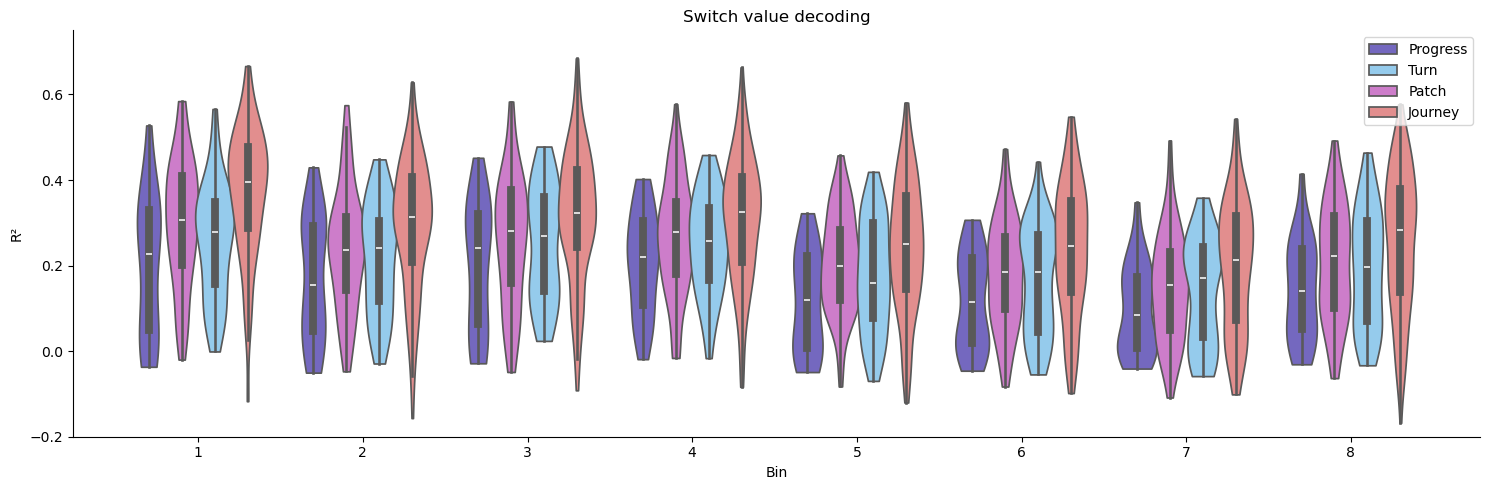

In [73]:
save_fig = True
n_bins = r2_valdiff_prog_array.shape[1]
group_labels = [f'{i+1}' for i in range(n_bins)]

df_prog = melt_array(r2_valdiff_prog_array, 'Progress')
df_turn = melt_array(r2_valdiff_turn_array, 'Turn')
df_patch = melt_array(r2_valdiff_patchprog_array, 'Patch')
df_journey = melt_array(r2_valdiff_pos_array, 'Journey')
df_all = pd.concat([df_prog, df_turn, df_patch,df_journey], ignore_index=True)

# df_prog_next = melt_array(r2_valdiffnext_array, 'Progress next trial')
# df_all = pd.concat([df_prog, df_prog_next], ignore_index=True)

# Assign manual numeric x positions with spacing
group_spacing = 1.5          # larger spacing between bins
condition_offset = 0.15        # small offset within each bin

x_map = {}
x_ticks = []
x_labels = []

for i, group in enumerate(group_labels):
    base_x = i * group_spacing
    if df_all.Condition.unique().shape[0] == 4:
        x_map[(group, 'Progress')] = base_x - 3*condition_offset
        x_map[(group, 'Patch')]     = base_x - 1*condition_offset
        x_map[(group, 'Turn')]     = base_x + 1*condition_offset
        x_map[(group, 'Journey')]     = base_x + 3*condition_offset
    if df_all.Condition.unique().shape[0] == 2:
        x_map[(group, 'Progress')] = base_x - 1.2*condition_offset
        x_map[(group, 'Progress next trial')]     = base_x + 1.2*condition_offset        
    x_ticks.append(base_x)
    x_labels.append(group)

# Assign numeric x values
df_all['x'] = df_all.apply(lambda row: x_map[(row['Bin'], row['Condition'])], axis=1)

# Plot
plt.figure(figsize=(15, 5))
sns.violinplot(data=df_all, x='x', y='Var explained',
               hue='Condition',
               palette={'Progress': 'slateblue','Turn': 'lightskyblue', 'Patch': 'orchid', 'Journey':'lightcoral'},
               # palette={'Progress': 'slateblue','Progress next trial': 'lightskyblue'},
               native_scale=True, cut=0, width=1.2, inner='box')

plt.ylim([-0.2,0.75])
# plt.ylim([0,0.7])
# Set custom x-ticks
plt.xticks(ticks=x_ticks, labels=x_labels)
plt.xlabel("Bin")
plt.ylabel("R²")
plt.title("Switch value decoding")
plt.legend(loc='upper right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

if save_fig:
    if df_all.Condition.unique().shape[0] == 4:
        figname = f'j16+wilbur+senor+peanut_{method}_ValVarExplainedByNeu_ProgTurnPatchJourney_{value_string}_ActiveNeurons_{len(plot_files)}DecayDays{selected_trials}_ViolinPlot.pdf'
    if df_all.Condition.unique().shape[0] == 2:
        figname = f'j16+wilbur+senor+peanut_{method}_ValVarExplainedByNeu_ThisVsNextTrialVal_{value_string}_ActiveNeurons_{len(plot_files)}DecayDays{selected_trials}_ViolinPlot.pdf'        
    plt.savefig(fig_dir+f"{behav_model}_value/"+figname, transparent = True)


#### Make line plots with SEM of value decoders
All days of each rat, or Early vs. Late learning

[19] [22 23]


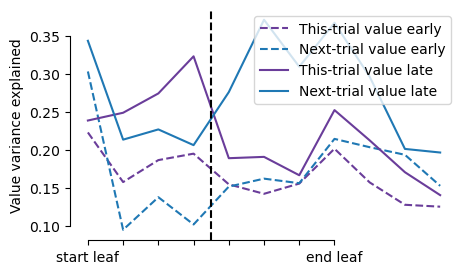

In [247]:
# Compare value var explained by different decoders
savefig = 0
colormap = cm.Paired(np.linspace(0,1,12))
method = "LASSO"
value_string = "valdiffmax"
ylabel = "Value variance explained"
plot_mean_only = True
animal = 'peanut'
early_days = {'j16':'j1620210714','wilbur':'wilbur20210404','senor':'senor20201109','peanut':'peanut20201203'}
late_days = {'j16':['j1620210718','j1620210719'],'wilbur':['wilbur20210408','wilbur20210409','wilbur20210410'],\
             'senor':['senor20201113','senor20201114','senor20201116'],'peanut':['peanut20201208','peanut20201209']}
if plot_mean_only:
    selected_files_e = early_days[animal]
    selected_files_l = late_days[animal]
    idx_e = np.where(np.isin(plot_files,selected_files_e))[0]
    idx_l = np.where(np.isin(plot_files,selected_files_l))[0]
    print(idx_e,idx_l)
else:
    idx = [i for i, name in enumerate(plot_files) if animal in name] # get data indices associated with a given rat (data array contains all days of all rats)

if 'r2_valdiffnext_array' in locals():
    # figname = f"{behav_model}_value/{animal}_{method}_ValVarExplainedByNeu_ThisVsNextTrialVal_{value_string}_ActiveNeurons_{len(idx)}DecayDays{selected_trials}_LinePlot.pdf"
    figname = f"{behav_model}_value/{animal}_{method}_ValVarExplainedByNeu_ThisVsNextTrialVal_{value_string}_ActiveNeurons_EarlyVsLateDays{selected_trials}_LinePlot.pdf"
    # plot_mean_with_sem([r2_valdiff_array[idx,:],r2_valdiffnext_array[idx,:]],\
                       # ["This-trial value","Next-trial value"],ylabel,f"{behav_model}_value/"+figname,savefig,colormap[[9,1],:],mean_only=plot_mean_only)
    plot_mean_with_sem([r2_valdiff_array[idx_e,:],r2_valdiffnext_array[idx_e,:],r2_valdiff_array[idx_l,:],r2_valdiffnext_array[idx_l,:]],\
                       ["This-trial value early","Next-trial value early","This-trial value late","Next-trial value late"],ylabel,\
                        figname,savefig,colormap[[9,1,9,1],:],line_styles=["--","--","-","-"],mean_only=plot_mean_only)
else:
    figname = f"{animal}_{method}_ValVarExplainedByNeu_ProgVsTurnVsPatchVsPos_{value_string}_ActiveNeurons_{len(idx)}DecayDays{selected_trials}_LinePlot.pdf"
    plot_mean_with_sem([r2_valdiff_prog_array_subsampled,r2_valdiff_prog_array,r2_valdiff_turn_array_subsampled,r2_valdiff_turn_array,r2_valdiff_pos_array],\
                       ["Progression subsampled","Progression","Action subsampled","Action","Position"],ylabel,f"{behav_model}_value/"+figname,savefig,colormap[[9,1,7,5,3],:])


#### Make dot plots of r2 of val_this_trial and val_next_trial for early vs late days, per animal

In [ ]:
early_days = {'j16':'j1620210714','wilbur':'wilbur20210404','senor':'senor20201109','peanut':'peanut20201203'}
late_days = {'j16':['j1620210718','j1620210719'],'wilbur':['wilbur20210408','wilbur20210409','wilbur20210410'],\
             'senor':['senor20201113','senor20201114','senor20201116'],'peanut':['peanut20201208','peanut20201209']}


In [27]:
if not 'r2this_early' in locals():
    r2this_early = dict()
    r2this_late = dict()
    r2next_early = dict()
    r2next_late = dict()

for animal in ['j16','wilbur','senor','peanut']:
    selected_files_e = early_days[animal]
    selected_files_l = late_days[animal]
    idx_e = np.where(np.isin(plot_files,selected_files_e))[0]
    idx_l = np.where(np.isin(plot_files,selected_files_l))[0]
    print(idx_e,idx_l)
    r2this_early[animal] = [r2_valdiff_array[idx_e,:].mean(axis=0)[:4].mean(),r2_valdiff_array[idx_e,:].mean(axis=0)[4:8].mean(),r2_valdiff_array[idx_e,:].mean(axis=0)[8:].mean()]
    r2this_late[animal] = [r2_valdiff_array[idx_l,:].mean(axis=0)[:4].mean(),r2_valdiff_array[idx_l,:].mean(axis=0)[4:8].mean(),r2_valdiff_array[idx_l,:].mean(axis=0)[8:].mean()]
    r2next_early[animal] = [r2_valdiffnext_array[idx_e,:].mean(axis=0)[:4].mean(),r2_valdiffnext_array[idx_e,:].mean(axis=0)[4:8].mean(),r2_valdiffnext_array[idx_e,:].mean(axis=0)[8:].mean()]
    r2next_late[animal] = [r2_valdiffnext_array[idx_l,:].mean(axis=0)[:4].mean(),r2_valdiffnext_array[idx_l,:].mean(axis=0)[4:8].mean(),r2_valdiffnext_array[idx_l,:].mean(axis=0)[8:].mean()]


[0] [4 5]
[6] [10 11 12]
[13] [15 16 17]
[19] [22 23]


saving betalik_value/j16+wilbur+senor+peanut_LASSO_ValVarExplainedByNeu_ThisVsNextTrialVal_valdiffmaxnext_ActiveNeurons_EarlyDays_DotPlot_Addbaseline.pdf


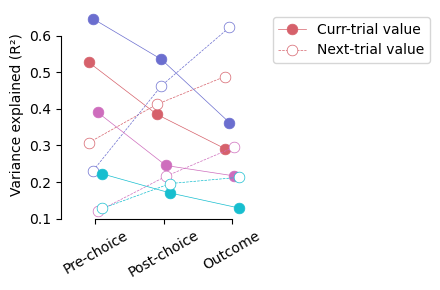

In [42]:
save_fig = True
day_str = 'Early'
# day_str = 'Late'
if day_str == 'Early':
    plot_metric1 = r2this_early
    plot_metric2 = r2next_early
if day_str == 'Late':
    plot_metric1 = r2this_late
    plot_metric2 = r2next_late

animals = list(r2this_early.keys())
N = len(next(iter(r2this_early.values())))
colormap1 = cm.tab20b(np.linspace(0,1,20))
colormap2 = cm.tab20(np.linspace(0,1,20))
colors= np.concatenate((colormap1[[14,2,18],:],colormap2[[-2],:]))

fig, ax = plt.subplots(figsize=(4.5, 3))
x_positions = np.arange(N)

jitter = np.linspace(-0.1, 0.1, len(animals))

# Loop over each animal
for j, animal in enumerate(animals):
    y1 = plot_metric1[animal]
    y2 = plot_metric2[animal]

    x_j = x_positions + jitter[j]

    ax.plot(x_j, y1, 'o-', color=colors[j,:], markerfacecolor=colors[j,:],markersize=7.7,
            markeredgecolor=None, markeredgewidth=0.5, lw=0.5, label='Curr-trial value' if j == 0 else "")

    ax.plot(x_j, y2, 'o--', color=colors[j,:], markerfacecolor='white',markersize=7.7,
            markeredgecolor=colors[j,:], markeredgewidth=0.5, lw=0.5, label='Next-trial value' if j == 0 else "")

ax.set_xticks(x_positions)
ax.set_xticklabels(['Pre-choice','Post-choice','Outcome'],rotation = 30)
ax.set_xlim(-0.5, N - 0.5)
if day_str == 'Early':
    ax.set_ylim(0.1,0.67) # Early days
if day_str == 'Late':
    ax.set_ylim(0.05,0.52) # Late days
ax.set_ylabel('Variance explained (R²)')
ax.legend(frameon=True,bbox_to_anchor=(1,1))
sns.despine(trim=True,left=False)
plt.tight_layout()

if save_fig:
    figname = f"{behav_model}_value/j16+wilbur+senor+peanut_{method}_ValVarExplainedByNeu_ThisVsNextTrialVal_{value_string}_ActiveNeurons_{day_str}Days{selected_trials}_DotPlot.pdf"
    print('saving',figname)
    plt.savefig(fig_dir+figname,transparent=True)

## 2. Fit LASSO with held-out single trials


### Fit the model

In [40]:
behav_model = 'betalik'
file_names = ['j1620210714','j1620210715','j1620210716','j1620210717','j1620210718','j1620210719',\
              'wilbur20210404','wilbur20210405','wilbur20210406','wilbur20210407','wilbur20210408','wilbur20210409','wilbur20210410',\
              'senor20201109','senor20201111','senor20201113','senor20201114','senor20201116','senor20201121',\
              'peanut20201203','peanut20201205','peanut20201206','peanut20201208','peanut20201209',\
              ]
# file_names = ['j1620210717','j1620210718','wilbur20210407','wilbur20210409','wilbur20210410','senor20201114','senor20201116','peanut20201206','peanut20201209'] # single-visit days
# file_names = ['wilbur20210404','wilbur20210408','wilbur20210409','wilbur20210410','j1620210714','j1620210718','j1620210719','senor20201109',\
#               'senor20201113','senor20201114','senor20201116','peanut20201203','peanut20201208','peanut20201209','senor20201121'] # Early- vs. Late-learning days


if_norm_neural = ""

bins_per_seg = 4

add_leaf = True
normalize_neural = False
transform_neural = False
from_best_stem = False
special_cases = False
one_poke_trial = False
rewarded_one_poke = False # Only tune this variable when looking at one-poke trials.
rewarded_switch_before_stay = False # Bouts where the animal stayed for 1+ trials after a rewarded switch; if false: the animal stayed for 1+ trials after an unrewarded switch
train_with_selected_sessions = True
save_results = True
incl_pause_time = True
use_updated_value = True # MUST be true if we include pause time and want to show update during pause time.
normalize_DVs = False # No normalization if we want to compare across days.

# trial_alignment = 'trial_id_before_switch'
trial_alignment = 'trial_id_after_switch'
    
# DVs = ['expected_value','past_value']
DVs = ['value_difference_max']
# DVs = ['value_difference_next']

# bin_types = ['prog','turn','patchprog']    
bin_types = ['prog']   
n_combined_bins = 0
    
for file_name in file_names:
    peri_switch_ids = np.arange(-8,1,1)
    if np.isin(file_name,['peanut20201205','peanut20201206','peanut20201208','senor20201113','chimi20200305','chimi20200308']):
        peri_switch_ids = np.arange(-6,1,1)
    if np.isin(file_name,['j1620210718','j1620210719']) & one_poke_trial:
        peri_switch_ids = np.arange(-6,1,1)
    if np.isin(file_name,['senor20201121','peanut20201209','senor20201114','senor20201116','chimi20200311']):
        peri_switch_ids = np.arange(-5,1,1)
    
    # Determine whether we exclude certain sessions from analysis. TODO: make an automated criteria based on behaviora performance or something.
    if np.isin(file_name,['j1620210719','wilbur20210408','wilbur20210409',\
                          'senor20201113','senor20201114','senor20201116','senor20201121',\
                          'peanut20201205','peanut20201206','peanut20201208','peanut20201209','chimi20200311']):
        use_selected_sessions = True
    else:
        use_selected_sessions = False
        
    if not from_best_stem:
        peri_switch_ids = np.arange(-4,1,1)
        if np.isin(file_name,['senor20201114','senor20201116']):
            peri_switch_ids = np.arange(-3,1,1)
    if trial_alignment == 'trial_id_after_switch':
        peri_switch_ids = (-peri_switch_ids)[::-1]

    print(f"fitting {file_name}")
    
    sess_selected,data_df_selected,pos_indicator_df,turn_indicator_df,patch_indicator_df,progress_indicator_df,spikes_by_posbins,all_units,predictor_neurons = \
    get_neural_behav_data_for_regression(file=file_name,selected_trials=selected_trials,incl_pause_time=incl_pause_time,add_leaf=add_leaf,\
                                         selected_neurons=neuron_str,use_updated_value=use_updated_value,use_selected_sessions=use_selected_sessions)

    if normalize_DVs:
        for DV_type in DVs:
            data_df_selected[DV_type] = (data_df_selected[DV_type]-data_df_selected[DV_type].mean())/data_df_selected[DV_type].std()
    
    df_stay = data_df_selected[data_df_selected['stem_switch']==False]
    df_switch = data_df_selected[data_df_selected['stem_switch']==True]

    for bin_type in bin_types:
        if n_combined_bins == 0:
            if bin_type == 'prog':
                selected_pos_columns = np.arange(0,progress_indicator_df.shape[1],1)
                selected_bins = progress_indicator_df.columns[selected_pos_columns]
            if bin_type == 'turn':
                selected_pos_columns = np.arange(0,turn_indicator_df.shape[1],1)
                selected_bins = turn_indicator_df.columns[selected_pos_columns]
            if bin_type == 'patchprog':    
                selected_pos_columns = np.arange(0,patch_indicator_df.shape[1],1)
                selected_bins = patch_indicator_df.columns[selected_pos_columns]
        else:
            if bin_type == 'prog':
                selected_pos_columns = np.array([0])
                selected_bins = progress_indicator_df.columns[selected_pos_columns]
            if bin_type == 'turn':
                selected_pos_columns = np.array([0,bins_per_seg*2]) # Combine bins per turn type
                selected_bins = turn_indicator_df.columns[selected_pos_columns]
            if bin_type == 'patchprog':
                selected_pos_columns = np.array([0,bins_per_seg*2,bins_per_seg*3]) # Combine bins per patch type
                selected_bins = patch_indicator_df.columns[selected_pos_columns]
        print(f'fitting {bin_type},total {selected_bins.shape[0]} bins')
        
        for DV in DVs:
            y_pred = dict()
            y_test = dict()
            test_trial_ids = dict()
            beta_value = np.empty((0,predictor_neurons.shape[0]))
            if DV == 'value_difference_next':
                df_stay = df_stay.loc[df_stay.value_difference_next.notna()]
                df_switch = df_switch.loc[df_switch.value_difference_next.notna()]

            df_stay = df_stay.loc[df_stay[trial_alignment].notna()]
            df_switch = df_switch.loc[df_switch[trial_alignment].notna()]
            
            for peri_switch_id in peri_switch_ids:
                if peri_switch_id == 0:
                    df_train = df_stay
                    if from_best_stem:
                        df_test = df_switch[np.array(df_switch.start_stem==df_switch.best_stem)]
                        # df_test = df_switch[np.array(df_switch.start_stem==df_switch.best_stem) & np.array(df_switch.pokes_before_switch>1) & np.array(df_switch.pokes_before_switch<100)] # Stays at least once before the switch.
                        if one_poke_trial:
                            ##### If we only look at one-poke trials ######
                            # df_test = df_test[np.array(df_test.stem_switch_next==1)] ##### If the next trial is also a switch trial (this way we can find value expectation on the current switch trial before the one-poke strategy ends)
                            if rewarded_one_poke:
                                df_test = df_test[np.array(df_test.stem_switch_next==1) & np.array(df_test.this_outcome==1)] ##### If this trial is rewarded and the next trial is also a switch trial
                            else:
                                df_test = df_test[np.array(df_test.stem_switch_next==1) & np.array(df_test.this_outcome==0)] ##### If this trial is unrewarded and the next trial is also a switch trial
                    else:
                        df_test = df_switch[np.array(df_switch.end_stem==df_switch.best_stem)] # Switch into the best stem from other stems
                        # df_test = df_switch[np.array(df_switch.start_stem!=df_switch.best_stem) & np.array(df_switch.end_stem==df_switch.best_stem) & np.array(df_switch.pokes_before_switch>1)]# Stays at least once before switching into the Best Stem.
                        # df_test = df_switch[np.array(df_switch.start_stem!=df_switch.best_stem) & np.array(df_switch.pokes_before_switch>1) & np.array(df_switch.pokes_before_switch<100)]
                        if one_poke_trial:
                            ##### If we only look at one-poke trials ######
                            if rewarded_one_poke:
                                df_test = df_test[np.array(df_test.pokes_before_switch==1) & np.array(df_test.last_outcome==1)] ##### Only rewarded one-pokes
                            else:
                                df_test = df_test[np.array(df_test.pokes_before_switch==1) & np.array(df_test.last_outcome==0)] ##### Only unrewarded one-pokes
                    # Only run the follows when we select trials satisfying special cases
                    if (special_cases) and (not one_poke_trial) and (not from_best_stem): 
                        # We exclude one-poke switches if its switching into the best patch
                        if rewarded_switch_before_stay:
                            df_test = df_test[np.array(df_test.stem_switch_next==0) & np.array(df_test.this_outcome==1)]
                        else:
                            df_test = df_test[np.array(df_test.stem_switch_next==0) & np.array(df_test.this_outcome==0)]   
                    if (special_cases) and (not one_poke_trial) and (from_best_stem): 
                        # We don't exclude one-poke switches if its switching out of the best patch
                        if rewarded_switch_before_stay:
                            df_test = df_test[np.array(df_test.this_outcome==1)]
                        else:
                            df_test = df_test[np.array(df_test.this_outcome==0)]                             
                else:
                    # df_train = df_stay[df_stay[trial_alignment]!=peri_switch_id]
                    df_train = df_stay[(df_stay[trial_alignment]!=peri_switch_id) & np.array(df_stay.pokes_before_switch<100)] # Drop the last few trials of each session as there won't be any switch trials after them
                    if from_best_stem:
                        # Stay trials in the best patch
                        df_test = df_stay[np.logical_and(df_stay.end_stem==df_stay.best_stem,df_stay[trial_alignment]==peri_switch_id)]
                    else:
                        # Stay trials in the non-best patch
                        df_test = df_stay[np.logical_and(df_stay.end_stem!=df_stay.best_stem,df_stay[trial_alignment]==peri_switch_id)]
                    if (peri_switch_id == 1) and (special_cases) and (not one_poke_trial):
                        if rewarded_switch_before_stay:
                            df_test = df_test[df_test.last_outcome==1] # Only look at the first stay trials after a rewarded switch.
                        else:
                            df_test = df_test[df_test.last_outcome==0] # Only look at the first stay trials after an unwarded switch.
                print(f'For switch {peri_switch_id} trials, training switch trial ids {df_train[trial_alignment].unique()}')
                print(f"there are {df_test.shape[0]} test trials total")
                
                if train_with_selected_sessions:
                    sess_train = sess_selected
                    # sess_test = np.setdiff1d(sess_selected, sess_train)
                    sess_test = sess_selected[[0,1,2]]
                    print(f'Training sessions{sess_train.astype(int)}, testing sessions{sess_test.astype(int)}')
                    df_train = df_train[df_train['session'].isin(sess_train)]
                    df_test = df_test[df_test['session'].isin(sess_test)]
                    print(f"there are {df_test.shape[0]} test trials in the selected session")
                
                if incl_pause_time:
                    ###### TODO: convert the following lines into a function that can be reused.
                    bins_per_seg = 4
                    bins_all_segs = np.array([bins_per_seg,bins_per_seg,3]) # num of bins of start leaf, end leaf, pause time
                    first_bin = 1            
                    prog_bin_sequence = np.arange(first_bin,first_bin+bins_all_segs.sum())
                    
                    pos_indicator_df_train = convert_pos_and_time_to_indicators(df_train,bins_all_segs)
                    patch_indicator_df_train = create_patch_indicators_from_pos_and_time_indicators(pos_indicator_df_train,bins_all_segs,first_bin)
                    turn_indicator_df_train = create_turn_indicators_from_pos_and_time_indicators(pos_indicator_df_train,bins_all_segs,first_bin)
                    progress_indicator_df_train = create_progress_indicators_from_turn_indicators(turn_indicator_df_train,prog_bin_sequence)
        
                    pos_indicator_df_test = convert_pos_and_time_to_indicators(df_test,bins_all_segs)
                    patch_indicator_df_test = create_patch_indicators_from_pos_and_time_indicators(pos_indicator_df_test,bins_all_segs,first_bin)
                    turn_indicator_df_test = create_turn_indicators_from_pos_and_time_indicators(pos_indicator_df_test,bins_all_segs,first_bin)
                    progress_indicator_df_test = create_progress_indicators_from_turn_indicators(turn_indicator_df_test,prog_bin_sequence)
                else:
                    first_bin = 1
                    bins_all_segs = np.array([bins_per_seg,bins_per_seg]) # num of bins of start leaf, end leaf
                    prog_bin_sequence = np.arange(first_bin,first_bin+bins_all_segs.sum())            
        
                    pos_indicator_df_train = convert_pos_and_time_to_indicators(df_train,bins_all_segs)
                    patch_indicator_df_train = create_patch_indicators_from_pos_and_time_indicators(pos_indicator_df_train,bins_all_segs,first_bin)            
                    turn_indicator_df_train = create_turn_indicators_from_pos_and_time_indicators(pos_indicator_df_train,bins_all_segs,first_bin)
                    progress_indicator_df_train = create_progress_indicators_from_turn_indicators(turn_indicator_df_train,prog_bin_sequence)
        
                    pos_indicator_df_test = convert_pos_and_time_to_indicators(df_test,bins_all_segs)
                    patch_indicator_df_test = create_patch_indicators_from_pos_and_time_indicators(pos_indicator_df_test,bins_all_segs,first_bin)
                    turn_indicator_df_test = create_turn_indicators_from_pos_and_time_indicators(pos_indicator_df_test,bins_all_segs,first_bin)
                    progress_indicator_df_test = create_progress_indicators_from_turn_indicators(turn_indicator_df_test,prog_bin_sequence)
        
                spikes_by_posbins_train = (df_train.filter(regex='spike_train')).iloc[:,np.isin(all_units,predictor_neurons)]
                spikes_by_posbins_test = (df_test.filter(regex='spike_train')).iloc[:,np.isin(all_units,predictor_neurons)]
                
                for bin_name in selected_bins:
                    if selected_pos_columns.shape[0] == patch_indicator_df_train.shape[1]:
                        # Fit every patch-based bin
                        data_index_train = patch_indicator_df_train[bin_name]==1
                        data_index_test = patch_indicator_df_test[bin_name]==1
                    else:
                        if selected_pos_columns.shape[0] == turn_indicator_df_train.shape[1]:
                            # Fit every action-based bin
                            data_index_train = turn_indicator_df_train[bin_name]==1
                            data_index_test = turn_indicator_df_test[bin_name]==1
                        else:
                            if selected_pos_columns.shape[0] == progress_indicator_df_train.shape[1]:
                                # Fit every progression-based bin
                                data_index_train = progress_indicator_df_train[bin_name]==1
                                data_index_test = progress_indicator_df_test[bin_name]==1
                            else: 
                                # combine bins to derive the average value axis
                                if bin_type == 'prog':
                                    n = np.where(selected_bins==bin_name)[0][0]
                                    data_index_train = (progress_indicator_df_train.iloc[:,selected_pos_columns[n]:selected_pos_columns[n]+n_combined_bins].sum(axis=1))==1 # Combine every n_combined_bins bins
                                    data_index_test = (progress_indicator_df_test.iloc[:,selected_pos_columns[n]:selected_pos_columns[n]+n_combined_bins].sum(axis=1))==1 # Combine every n_combined_bins bins
                                if bin_type == 'turn':
                                    n = np.where(selected_bins==bin_name)[0][0]
                                    data_index_train = (turn_indicator_df_train.iloc[:,selected_pos_columns[n]:selected_pos_columns[n]+n_combined_bins].sum(axis=1))==1 # Combine every n_combined_bins bins
                                    data_index_test = (turn_indicator_df_test.iloc[:,selected_pos_columns[n]:selected_pos_columns[n]+n_combined_bins].sum(axis=1))==1 # Combine every n_combined_bins bins
                    
                    X_train = (spikes_by_posbins_train.div(df_train['occupancy'],axis=0))[data_index_train]
                    y_train = (df_train[DV])[data_index_train]
                    X_test = (spikes_by_posbins_test.div(df_test['occupancy'],axis=0))[data_index_test]
                    X_all = spikes_by_posbins.div(data_df_selected['occupancy'],axis=0)
                    if normalize_neural:
                        X_train = (X_train - X_all.mean()) / X_all.std()
                        X_test = (X_test - X_all.mean()) / X_all.std()
                        if_norm_neural='_NormNeural'
                    if transform_neural:
                        X_train = np.log(X_train+0.1)
                        X_test = np.log(X_test+0.1)
                    reg = LassoCV(cv=5, max_iter=10000, random_state=100, n_alphas=200).fit(X_train, y_train)
                    model_best = Lasso(alpha=reg.alpha_)
                    model_best.fit(X_train,y_train)
                    beta_value = np.vstack((beta_value,model_best.coef_))
                    y_pred[bin_name+f' trial {peri_switch_id}'] = model_best.predict(X_test)
                    y_test[bin_name+f' trial {peri_switch_id}'] = np.array((df_test[DV])[data_index_test])
                    test_trial_ids[bin_name+f' trial {peri_switch_id}'] = df_test.trial_id.unique()
        
            if DV == 'expected_value':
                DV_string = 'expval'
            if DV == 'past_value':
                DV_string = 'pastval'
            if DV == 'value_difference_max':
                DV_string = 'valdiffmax'
                    
            print(f'Trial alignment {trial_alignment}\n Done!')
        
            if save_results:
                if from_best_stem:
                    save_name = results_dir+f"{behav_model}_value/"+file_name+f"_single_trial_{DV_string}_prediction_{neuron_str}_{selected_pos_columns.shape[0]}{bin_type}bins_trial{peri_switch_ids[0]}to{peri_switch_ids[-1]}_from_beststem{if_norm_neural}.npz"
                else:
                    save_name = results_dir+f"{behav_model}_value/"+file_name+f"_single_trial_{DV_string}_prediction_{neuron_str}_{selected_pos_columns.shape[0]}{bin_type}bins_trial{peri_switch_ids[0]}to{peri_switch_ids[-1]}_from_nonbeststem{if_norm_neural}.npz"
                if one_poke_trial:
                    if rewarded_one_poke:
                        save_name = save_name[:-4]+"_one_poke_rewarded.npz"
                    else:
                        save_name = save_name[:-4]+"_one_poke_unrewarded.npz"
                else:
                    if special_cases:
                        if rewarded_switch_before_stay:
                            save_name = save_name[:-4]+"_rewarded_first_trial.npz"
                        else:
                            save_name = save_name[:-4]+"_unrewarded_first_trial.npz"
                if normalize_DVs:
                    save_name = save_name[:-4]+f"_normalizedval.npz"
                else:
                    save_name = save_name[:-4]+f"_unnormalizedval.npz"
                if use_selected_sessions:
                    save_name = save_name[:-4]+f"_r{''.join(str(int(n)) for n in sess_selected)}.npz"
                if train_with_selected_sessions:
                    save_name = save_name[:-4]+f"_r{''.join(str(int(n)) for n in sess_train)}train+r{''.join(str(int(n)) for n in sess_test)}test.npz"
                if add_leaf:
                    save_name = save_name[:-4]+"_addleaf.npz"
                print(f'saving {save_name}')
                np.savez(save_name,y_test=y_test,y_pred=y_pred,test_trial_ids=test_trial_ids,beta_value=beta_value,allow_pickle=True)
                

fitting wilbur20210404
loading /home/xulu/code/preliminary_data/wilbur20210404_ValueDecision/wilbur20210404_data_df_NoSmooth_mPFC_11bins_WithOutcome+RewardHist+ExpVal+PatchVal+PastVal+ValueDiff+ValueDiffMax+AltValue+StemStayP+SwitchTrialID+HeadDir+HeadAngle+Velocity_addleaf.pkl
There are 389 active neurons.
There are 260 value neurons.
There are 229 decision neurons.
selected sessions [1. 2. 3. 4. 5.]
There're 16368 datapoints for regression.
fitting prog,total 11 bins
For switch 0 trials, training switch trial ids [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19.]
there are 858 test trials total
Training sessions[1 2 3 4 5], testing sessions[1 2 3]
there are 462 test trials in the selected session
For switch 1 trials, training switch trial ids [ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19.]
there are 1386 test trials total
Training sessions[1 2 3 4 5], testing sessions[1 2 3]
there are 770 test trials in the selected session
For sw

## 3. Load decoding results and calculate meta-learning related neural changes


### Load decoded value

In [41]:
# Define a few string variables that will be used to load results of specific datasets.
subject = 'wilbur'
date = '20210404'
file_name = subject+date
behav_model = 'betalik'

add_leaf = True
incl_pause_time = True
use_updated_value = True
from_best_stem_cases = [True, False]
special_cases = False # Including one poke analysis and rewarded/unrewarded trials
one_poke_trial = False
rewarded_one_poke = False
rewarded_switch_before_stay = False
normalize_DVs = False
train_with_selected_sessions = True

if np.isin(file_name,['j1620210719','wilbur20210408','wilbur20210409',\
                      'senor20201113','senor20201114','senor20201116','senor20201121',\
                      'peanut20201205','peanut20201206','peanut20201208','peanut20201209','chimi20200311']):
    use_selected_sessions = True
else:
    use_selected_sessions = False

n_bins_per_journey = 8
if incl_pause_time:
    n_bins_per_journey = 11

bin_type = 'prog'
# bin_type = 'turn'
# bin_type = 'patchprog'
if bin_type == 'prog':
    bin_type_str = f'{n_bins_per_journey}prog'
if bin_type == 'turn':
    bin_type_str = f'{n_bins_per_journey*2}turn'
if bin_type == 'patchprog':
    bin_type_str = f'{n_bins_per_journey*3}patchprog'

DV = 'value_difference_max'
predictor_neuron_str = 'active_neurons_'
# predictor_neuron_str = ''

trial_alignment = 'trial_id_after_switch'
# trial_alignment = 'trial_id_before_switch'
if one_poke_trial:
    trial_alignment = 'trial_id_before_switch' # Ensure correct trial alignment for single-visit cases

for from_best_stem in from_best_stem_cases:
    peri_switch_ids = np.arange(-8,1,1)
    if np.isin(file_name,['peanut20201205','peanut20201206','peanut20201208','senor20201113','chimi20200305','chimi20200308']):
        peri_switch_ids = np.arange(-6,1,1)
    if np.isin(file_name,['j1620210718','j1620210719']) & one_poke_trial:
        peri_switch_ids = np.arange(-6,1,1)
    if np.isin(file_name,['senor20201121','peanut20201209','senor20201114','senor20201116','chimi20200311']):
        peri_switch_ids = np.arange(-5,1,1)
    if not from_best_stem:
        peri_switch_ids = np.arange(-4,1,1)
        if np.isin(file_name,['senor20201114','senor20201116']):
            peri_switch_ids = np.arange(-3,1,1)
    if trial_alignment == 'trial_id_after_switch':
        peri_switch_ids = (-peri_switch_ids)[::-1] 
    
    if use_selected_sessions:
        sess = find_specific_sessions(file_name,sess_orig=np.arange(1,6,1))
    
    if DV == 'value_difference_max':
        DV_string = 'valdiffmax'

    if from_best_stem:
        results_file = results_dir+f"{behav_model}_value/"+file_name+f"_single_trial_{DV_string}_prediction_{predictor_neuron_str}{bin_type_str}bins_trial{peri_switch_ids[0]}to{peri_switch_ids[-1]}_from_beststem.npz"    
    else:
        results_file = results_dir+f"{behav_model}_value/"+file_name+f"_single_trial_{DV_string}_prediction_{predictor_neuron_str}{bin_type_str}bins_trial{peri_switch_ids[0]}to{peri_switch_ids[-1]}_from_nonbeststem.npz"
    if special_cases:
        if one_poke_trial:
            if rewarded_one_poke:
                results_file = results_file[:-4] + '_one_poke_rewarded.npz'
            else:
                results_file = results_file[:-4] + '_one_poke_unrewarded.npz'
        else:
            if rewarded_switch_before_stay:
                results_file = results_file[:-4]+"_rewarded_first_trial.npz"
            else:
                results_file = results_file[:-4]+"_unrewarded_first_trial.npz"
    if normalize_DVs:
        results_file = results_file[:-4]+f"_normalizedval.npz"
    else:
        results_file = results_file[:-4]+f"_unnormalizedval.npz"
    if use_updated_value and special_cases:
        results_file = results_file[:-4]+f"_updatedval_cleaned.npz"
    if use_selected_sessions:
        results_file = results_file[:-4] + f"_r{''.join(str(int(n)) for n in sess)}.npz"
    if train_with_selected_sessions:
        results_file = results_file[:-4]+f"_r{''.join(str(int(n)) for n in sess_train)}train+r{''.join(str(int(n)) for n in sess_test)}test.npz"
    if add_leaf: # Use bata bernoulli estimates with leaf bias
        results_file = results_file[:-4]+f"_addleaf.npz"    
    a = np.load(results_file,allow_pickle=True)
    print(f'loaded {results_file}')
    
    y_test = a.f.y_test.item()
    y_pred = a.f.y_pred.item()
    test_trial_ids = a.f.test_trial_ids.item()

    # Assigned loaded results to specific arrays for different conditions
    plot_behavior = False # Whether we plot the HMM values (instead of neurally inferred values)
    combine_bins = False
    
    mean_pred,sem_pred = get_mean_and_sem_per_group(file_name,y_pred,bins_per_journey=n_bins_per_journey,bin_type=bin_type,combine_bins=combine_bins)
    if plot_behavior:
        mean_hmm,sem_hmm = get_mean_and_sem_per_group(file_name,y_test,bins_per_journey=n_bins_per_journey,bin_type=bin_type,combine_bins=combine_bins)
    
    if special_cases:
        if rewarded_switch_before_stay or rewarded_one_poke:
            if from_best_stem:
                y_pred_rewarded_best = y_pred
                trial_ids_rewarded_best = test_trial_ids
                mean_pred_rewarded_best = mean_pred
            else:
                y_pred_rewarded_nonbest = y_pred
                trial_ids_rewarded_nonbest = test_trial_ids
                mean_pred_rewarded_nonbest = mean_pred
        else:
            if from_best_stem:
                y_pred_unrewarded_best = y_pred
                trial_ids_unrewarded_best = test_trial_ids
                mean_pred_unrewarded_best = mean_pred
            else:
                y_pred_unrewarded_nonbest = y_pred
                trial_ids_unrewarded_nonbest = test_trial_ids
                mean_pred_unrewarded_nonbest = mean_pred
            
    if from_best_stem:
        print('assigning best stem predictions')
        y_pred_beststem = y_pred
        trial_ids_beststem = test_trial_ids
        mean_pred_beststem = mean_pred
        sem_pred_beststem = sem_pred
    else:
        print('assigning nonbest stem predictions')
        y_pred_otherstem = y_pred
        trial_ids_otherstem = test_trial_ids
        mean_pred_otherstem = mean_pred
        sem_pred_otherstem = sem_pred

loaded /home/xulu/code/preliminary_results/betalik_value/wilbur20210404_single_trial_valdiffmax_prediction_active_neurons_11progbins_trial0to8_from_beststem_unnormalizedval_r12345train+r123test_addleaf.npz
assigning best stem predictions
loaded /home/xulu/code/preliminary_results/betalik_value/wilbur20210404_single_trial_valdiffmax_prediction_active_neurons_11progbins_trial0to4_from_nonbeststem_unnormalizedval_r12345train+r123test_addleaf.npz
assigning nonbest stem predictions


### Neural value repletion: switch-out value - switch-in value

In [86]:
# Function to find successive switch-out and switch-in trial pairs for the same patch.
def match_next_larger(
    a: npt.ArrayLike, b: npt.ArrayLike
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Match each a[i] to the minimal unused b[j] such that b[j] > a[i], assuming
    both a and b are already sorted ascending. Unmatched elements are discarded.

    Parameters
    ----------
    a, b : array-like
        1D arrays sorted in ascending order.

    Returns
    -------
    a_matched : np.ndarray
        Matched values from a, shape (k,).
    b_matched : np.ndarray
        Corresponding matched values from b, shape (k,).
    """
    a_arr = np.asarray(a)
    b_arr = np.asarray(b)

    if a_arr.ndim != 1 or b_arr.ndim != 1:
        raise ValueError("a and b must be 1D arrays.")

    i = 0
    j = 0
    matched_a = []
    matched_b = []

    while i < a_arr.size and j < b_arr.size:
        if b_arr[j] > a_arr[i]:
            matched_a.append(a_arr[i])
            matched_b.append(b_arr[j])
            i += 1
            j += 1  # consume this b (no reuse)
        else:
            j += 1  # b too small (or equal), skip it

    return np.asarray(matched_a), np.asarray(matched_b)


In [87]:
a = np.asarray(trial_ids_beststem['bin 4 trial 0'])
b = trial_ids_otherstem['bin 5 trial 0']
pos = np.searchsorted(b, a, side="right")
result_idx = np.full(len(a), fill_value=-1, dtype=int)
valid = pos < len(b)
result_idx = pos[valid]

In [71]:
keys = [f"bin {i} trial 0" for i in np.arange(1,5,1)]
arrays = [np.asarray(y_pred_beststem[k]) for k in keys]
y_pred_beststem_mean = np.mean(np.stack(arrays, axis=0), axis=0)
keys = [f"bin {i} trial 0" for i in np.arange(5,9,1)]
arrays = [np.asarray(y_pred_otherstem[k]) for k in keys]
y_pred_otherstem_mean = np.mean(np.stack(arrays, axis=0), axis=0)

In [48]:
# Calculate switch-out to switch-in reset (neural value repletion)
if np.isin(file_name,['j1620210714','wilbur20210404','peanut20201203','senor20201109']):
    value_replete_early = y_pred_beststem_mean[:result_idx.shape[0]] - y_pred_otherstem_mean[result_idx]
    print(value_replete_early.shape)
else:
    if np.isin(file_name,['j1620210718','wilbur20210408','peanut20201208','senor20201113']):
        value_replete_late = y_pred_beststem_mean - y_pred_otherstem_mean[result_idx]
    else:
        value_replete_late = np.concatenate((value_replete_late,y_pred_beststem_mean - y_pred_otherstem_mean[result_idx]))
    print(value_replete_late.shape)

(43,)


In [448]:
if file_name[0] == 'j':
    animal_ind = 1
if file_name[0] == 'w':
    animal_ind = 2
if file_name[0] == 's':
    animal_ind = 3
if file_name[0] == 'p':
    animal_ind = 4
    
if np.isin(file_name,['j1620210714','wilbur20210404','senor20201109','peanut20201203']):
    early_sess = 1

else:
    early_sess = 0

if file_name == 'j1620210714':
    value_replete_allrats = pd.DataFrame({
        'Animal': np.ones(result_idx.shape[0])*animal_ind,
        'IsEarlySess': np.ones(result_idx.shape[0])*early_sess,
        'ValueReplete': y_pred_beststem_mean - y_pred_otherstem_mean[result_idx]
    })
else:
    value_replete_allrats = pd.concat((value_replete_allrats,\
                                           pd.DataFrame({
                                                'Animal': np.ones(result_idx.shape[0])*animal_ind,
                                                'IsEarlySess': np.ones(result_idx.shape[0])*early_sess,
                                                'ValueReplete': y_pred_beststem_mean - y_pred_otherstem_mean[result_idx]})))
    
value_replete_allrats

,Animal,IsEarlySess,ValueReplete
0,1.0,1.0,1.071152
1,1.0,1.0,1.474303
2,1.0,1.0,1.365023
3,1.0,1.0,1.811396
4,1.0,1.0,2.627498
...,...,...,...
101,4.0,0.0,1.024379
102,4.0,0.0,1.003491
103,4.0,0.0,0.576589
104,4.0,0.0,0.798120


In [449]:
save_results = True
if save_results:
    value_replete_allrats.to_pickle(results_dir+f"{behav_model}_value/"+'j16+wilbur+senor+peanut_neural_value_replete_switchin_vs_switchout_mixedlinear_early_late_days_addleaf.pkl')


In [452]:
# Mixed-effects model across all animals (random intercept per animal):
# ValueDiff ~ Reward * IsEarlySess  → includes Reward, IsEarlySess, and their interaction
# (1 | Animal)  → random intercept per Animal

model = smf.mixedlm(
    "ValueReplete ~ IsEarlySess",
    data=value_replete_allrats,
    groups=value_replete_allrats["Animal"]
)
result = model.fit()
print(result.summary())
print(result.params)             # estimates (fixed + variance params)
print(result.pvalues)            # p-values for fixed-effect coefficients


          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ValueReplete
No. Observations: 1495    Method:             REML        
No. Groups:       4       Scale:              0.8829      
Min. group size:  272     Log-Likelihood:     -2040.2499  
Max. group size:  492     Converged:          Yes         
Mean group size:  373.8                                   
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        1.952    0.405  4.816 0.000  1.158  2.747
IsEarlySess     -0.231    0.065 -3.581 0.000 -0.358 -0.105
Group Var        0.654    0.571                           

Intercept      1.952365
IsEarlySess   -0.231485
Group Var      0.741094
dtype: float64
Intercept      0.000001
IsEarlySess    0.000343
Group Var      0.222648
dtype: float64


### Additional processing before calculating metrics or plotting

In [19]:
# For CALCULATING value update differences between rewarded and unrewarded one pokes
if special_cases:
    if one_poke_trial: 
        ######### !!!!!!! DO NOT exchange postswitch bins when doing the following calculations !!!!!!!! ########
        if rewarded_one_poke:
            mean_rewarded_poke = mean_pred_otherstem[-1,:][0] # Last row is the single-poke switch trial
            mean_delta_rewarded_poke = mean_pred_otherstem[-1,:][0]-mean_pred_beststem[-1,:][-1]# Value update right after a rewarded one poke in the nonbest stem.
            sem_rewarded_poke = sem_pred_otherstem[-1,:][0]
            mean_slope_rewarded = mean_pred_otherstem[-1,3]-mean_pred_otherstem[-1,0] # How much is the value further updated right before switching compared to initial states of the switch trial
            delta_from_stay_rewarded = mean_pred_otherstem[-1,:4]-mean_pred_otherstem[:-1,:4].mean(axis=0) # Is the single-poke switch trial value more positive than the average of the stay trials in the same patch
        else:
            mean_unrewarded_poke = mean_pred_otherstem[-1,:][0] # Last row is the single-poke switch trial
            mean_delta_unrewarded_poke = mean_pred_otherstem[-1,:][0]-mean_pred_beststem[-1,:][-1]# Value update right after an unrewarded one poke in the nonbest stem.
            sem_unrewarded_poke = sem_pred_otherstem[-1,:][0]
            mean_slope_unrewarded = mean_pred_otherstem[-1,3]-mean_pred_otherstem[-1,0]
            delta_from_stay_unrewarded = mean_pred_otherstem[-1,:4]-mean_pred_otherstem[:-1,:4].mean(axis=0) # Is the single-poke switch trial value more positive than the average of the stay trials in the same patch
    
    # For CALCULATING value updates and value differences on switch+1 trial after reward/no reward (excluding one pokes)
    if not one_poke_trial:
        ######### !!!!!!! DO NOT exchange post-switch bins before running the following calculations !!!!!!!! ###########
        if rewarded_switch_before_stay:
            mean_pred_rewarded_switch = np.vstack((mean_pred_beststem[0,:],mean_pred_otherstem[0,:])) #row 0 is the switch trial
            mean_pred_rewarded_stay1 = np.vstack((mean_pred_beststem[1,:],mean_pred_otherstem[1,:])) #row 1 is the first stay trial after a switch
            mean_pred_rewarded_relative = np.vstack((mean_pred_beststem[1,:]-mean_pred_otherstem[0,-1],mean_pred_otherstem[1,:]-mean_pred_beststem[0,-1])) # From last bin of the switch to the first bin of switch+1
        else:
            mean_pred_unrewarded_switch = np.vstack((mean_pred_beststem[0,:],mean_pred_otherstem[0,:])) #row 0 is the switch trial
            mean_pred_unrewarded_stay1 = np.vstack((mean_pred_beststem[1,:],mean_pred_otherstem[1,:])) #row 1 is the first stay trial after a switch
            mean_pred_unrewarded_relative = np.vstack((mean_pred_beststem[1,:]-mean_pred_otherstem[0,-1],mean_pred_otherstem[1,:]-mean_pred_beststem[0,-1])) # From last bin of the switch to the first bin of switch+1


In [ ]:
###### ONLY use this when CALCULATING switch value slope for stay bouts. ########
combine_reward_conds = True
assert set(y_pred_rewarded_best) == set(y_pred_unrewarded_best)

# concatenate values per key (along axis=0 by default)
y_pred_best_comb = {
    k: np.concatenate([np.asarray(y_pred_rewarded_best[k]),
                       np.asarray(y_pred_unrewarded_best[k])], axis=0)
    for k in y_pred_rewarded_best
}
y_pred_nonbest_comb = {
    k: np.concatenate([np.asarray(y_pred_rewarded_nonbest[k]),
                       np.asarray(y_pred_unrewarded_nonbest[k])], axis=0)
    for k in y_pred_rewarded_nonbest
}
mean_pred_best_comb,_ = get_mean_and_sem_per_group(file_name,y_pred_best_comb,bins_per_journey=n_bins_per_journey,bin_type=bin_type,combine_bins=combine_bins)
mean_pred_nonbest_comb,_ = get_mean_and_sem_per_group(file_name,y_pred_nonbest_comb,bins_per_journey=n_bins_per_journey,bin_type=bin_type,combine_bins=combine_bins)

In [28]:
###### ONLY useful for PLOTTING not for calculating metrics. ########
exchange_postswitch = True
if exchange_postswitch:
    mean_pred_beststem_copy = np.copy(mean_pred_beststem)
    sem_pred_beststem_copy = np.copy(sem_pred_beststem)
    if trial_alignment == 'trial_id_after_switch': # First row is switch trial
        mean_pred_beststem[0,4:] = mean_pred_otherstem[0,4:]
        mean_pred_otherstem[0,4:] = mean_pred_beststem_copy[0,4:]
        sem_pred_beststem[0,4:] = sem_pred_otherstem[0,4:]
        sem_pred_otherstem[0,4:] = sem_pred_beststem_copy[0,4:]
    else: # Last row is switch trial
        mean_pred_beststem[-1,4:] = mean_pred_otherstem[-1,4:]
        mean_pred_otherstem[-1,4:] = mean_pred_beststem_copy[-1,4:]
        sem_pred_beststem[-1,4:] = sem_pred_otherstem[-1,4:]
        sem_pred_otherstem[-1,4:] = sem_pred_beststem_copy[-1,4:]

In [29]:
# ONLY for PLOTTING rewarded/unrewarded switch+1: compare switch+1 decoded value after reward/no reward (excluding one pokes)
if special_cases:
    if not one_poke_trial:
        ######### !!!!!!! DO NOT exchange post-switch bins before running the following calculations !!!!!!!! ###########
        if rewarded_switch_before_stay:
            if use_updated_value:
                mean_pred_rewarded = np.vstack((mean_pred_beststem[0,:],mean_pred_otherstem[0,:])) #row 0 is the switch trial; only useful for plotting 11-prog to show value update
                sem_pred_rewarded = np.vstack((sem_pred_beststem[0,:],sem_pred_otherstem[0,:]))
            else:
                mean_pred_rewarded = np.vstack((mean_pred_beststem[1,:],mean_pred_otherstem[1,:])) #row 1 is the first stay trial after a switch
                sem_pred_rewarded = np.vstack((sem_pred_beststem[1,:],sem_pred_otherstem[1,:]))        
        else:
            if use_updated_value:
                mean_pred_unrewarded = np.vstack((mean_pred_beststem[0,:],mean_pred_otherstem[0,:])) #row 0 is the switch trial
                sem_pred_unrewarded = np.vstack((sem_pred_beststem[0,:],sem_pred_otherstem[0,:]))
            else:
                mean_pred_unrewarded = np.vstack((mean_pred_beststem[1,:],mean_pred_otherstem[1,:])) #row 1 is the first stay trial after a switch
                sem_pred_unrewarded = np.vstack((sem_pred_beststem[1,:],sem_pred_otherstem[1,:]))
    
    # ONLY for PLOTTING rewarded/unrewarded one pokes: one-poke decoded value w/wo reward
    if one_poke_trial:
        ######### !!!!!!! DO NOT exchange post-switch bins before running the following calculations !!!!!!!! ###########
        if rewarded_one_poke:
            mean_pred_rewarded = np.vstack((mean_pred_beststem[-1,:],mean_pred_otherstem[-1,:])) #last row is the switch trial
            sem_pred_rewarded = np.vstack((sem_pred_beststem[-1,:],sem_pred_otherstem[-1,:]))
        else:
            mean_pred_unrewarded = np.vstack((mean_pred_beststem[-1,:],mean_pred_otherstem[-1,:]))
            sem_pred_unrewarded = np.vstack((sem_pred_beststem[-1,:],sem_pred_otherstem[-1,:]))


### Dataframe of stay 1 value and switch out value (early & late days of all rats)

In [114]:
stay1_bins = [f'bin {i} trial 1' for i in [1,2,3,4]]
switchout_bins = [f'bin {i} trial 0' for i in [1,2,3,4]]

stay1_val_best = np.mean(np.stack([y_pred_beststem[k] for k in stay1_bins], axis=0), axis=0)
switchout_val_best = np.mean(np.stack([y_pred_beststem[k] for k in switchout_bins], axis=0), axis=0)
is_stay_best = np.concatenate((np.ones(stay1_val_best.shape),np.zeros(switchout_val_best.shape)))

stay1_val_nonbest = np.mean(np.stack([y_pred_otherstem[k] for k in stay1_bins], axis=0), axis=0)
switchout_val_nonbest = np.mean(np.stack([y_pred_otherstem[k] for k in switchout_bins], axis=0), axis=0)
is_stay_nonbest = np.concatenate((np.ones(stay1_val_nonbest.shape),np.zeros(switchout_val_nonbest.shape)))

In [115]:
if file_name[0] == 'j':
    animal_ind = 1
if file_name[0] == 'w':
    animal_ind = 2
if file_name[0] == 's':
    animal_ind = 3
if file_name[0] == 'p':
    animal_ind = 4
    
if np.isin(file_name,['j1620210714','wilbur20210404','senor20201109','peanut20201203']):
    early_sess = 1

else:
    early_sess = 0

if file_name == 'j1620210714':
    prechoice_val_best_allrats = pd.DataFrame({
        'Animal': np.ones(is_stay_best.shape[0])*animal_ind,
        'IsEarlySess': np.ones(is_stay_best.shape[0])*early_sess,
        'IsStay': is_stay_best,
        'Value': np.concatenate((stay1_val_best,switchout_val_best))
    })
    
    prechoice_val_nonbest_allrats = pd.DataFrame({
        'Animal': np.ones(is_stay_nonbest.shape[0])*animal_ind,
        'IsEarlySess': np.ones(is_stay_nonbest.shape[0])*early_sess,
        'IsStay': is_stay_nonbest,
        'Value': np.concatenate((stay1_val_nonbest,switchout_val_nonbest))
    })
else:
    prechoice_val_best_allrats = pd.concat((prechoice_val_best_allrats,\
                                           pd.DataFrame({
                                                'Animal': np.ones(is_stay_best.shape[0])*animal_ind,
                                                'IsEarlySess': np.ones(is_stay_best.shape[0])*early_sess,
                                                'IsStay': is_stay_best,
                                                'Value': np.concatenate((stay1_val_best,switchout_val_best))})))
    prechoice_val_nonbest_allrats = pd.concat((prechoice_val_nonbest_allrats,\
                                              pd.DataFrame({
                                                'Animal': np.ones(is_stay_nonbest.shape[0])*animal_ind,
                                                'IsEarlySess': np.ones(is_stay_nonbest.shape[0])*early_sess,
                                                'IsStay': is_stay_nonbest,
                                                'Value': np.concatenate((stay1_val_nonbest,switchout_val_nonbest))})))
    
prechoice_val_best_allrats

,Animal,IsEarlySess,IsStay,Value
0,1.0,1.0,1.0,-4.185608
1,1.0,1.0,1.0,-3.478581
2,1.0,1.0,1.0,-3.568597
3,1.0,1.0,1.0,-4.565599
4,1.0,1.0,1.0,-5.328409
...,...,...,...,...
225,4.0,0.0,0.0,-2.338243
226,4.0,0.0,0.0,-2.226081
227,4.0,0.0,0.0,-2.715991
228,4.0,0.0,0.0,-2.593342


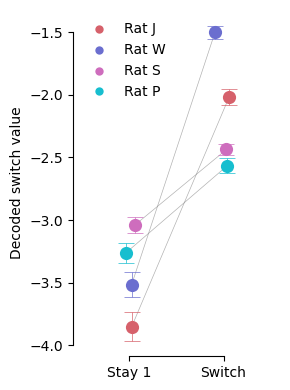

In [197]:
save_fig = False
figname = ""
metric_name = "Value"
save_metric = "decoded_switch_value"
if save_fig:   
    # figname = fig_dir+f"{behav_model}_value/"+f"j16+wilbur+senor+peanut_{save_metric}_stay1_vs_switchout_beststem_latedays_dotplot.pdf"
    figname = fig_dir+f"{behav_model}_value/"+f"j16+wilbur+senor+peanut_{save_metric}_stay1_vs_switchout_nonbeststem_earlydays_dotplot.pdf"

ax, summary = plot_value_metric_grouped_by_conditions(prechoice_val_best_allrats[prechoice_val_best_allrats['IsEarlySess']==0], value_metric=metric_name, cond="IsStay", add_reference=False, connect_pairs=True, point_size=90, n_boot=10000, alpha=0.05, jitter=0.07, seed=1, save_name=figname)
# ax, summary = plot_value_metric_grouped_by_conditions(prechoice_val_nonbest_allrats[prechoice_val_nonbest_allrats['IsEarlySess']==1], value_metric=metric_name, cond="IsStay", add_reference=False, connect_pairs=True, point_size=90, n_boot=10000, alpha=0.05, jitter=0.05, seed=15, save_name=figname)


In [182]:
# Mixed-effects model within each animal:
results = {}
pvals = {}
animals = ['j16','wilbur','senor','peanut']
# for animal, df_animal in prechoice_val_best_allrats[prechoice_val_best_allrats['IsEarlySess']==0].groupby("Animal"):
#     model = smf.ols("Value ~ IsStay", data=df_animal).fit()
#     results[animal] = model.summary()
#     pvals[animal] = model.pvalues
#     print(f"\n===== Animal {animals[int(animal-1)]} =====")
#     print(model.summary().tables[1])  # show coefficients table only
#     print(pvals[animal])           # p-values for fixed-effect coefficients

for animal, df_animal in prechoice_val_nonbest_allrats[prechoice_val_nonbest_allrats['IsEarlySess']==1].groupby("Animal"):
    model = smf.ols("Value ~ IsStay", data=df_animal).fit()
    results[animal] = model.summary()
    pvals[animal] = model.pvalues
    print(f"\n===== Animal {animals[int(animal-1)]} =====")
    print(model.summary().tables[1])  # show coefficients table only
    print(pvals[animal])           # p-values for fixed-effect coefficients


===== Animal j16 =====
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.5099      0.093    -26.937      0.000      -2.694      -2.326
IsStay        -2.2808      0.115    -19.843      0.000      -2.507      -2.054
Intercept    9.486890e-70
IsStay       7.124788e-50
dtype: float64

===== Animal wilbur =====
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.7658      0.129    -13.676      0.000      -2.020      -1.511
IsStay        -3.1227      0.165    -18.949      0.000      -3.448      -2.798
Intercept    1.720269e-30
IsStay       1.596997e-46
dtype: float64

===== Animal senor =====
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

### Linear mixed effects test on how reward affects value updates in early & late days

In [75]:
pause_bins = [f'bin {i} trial 0' for i in [9,10,11]]
####### Best stem #######
# assert y_pred_rewarded_best['bin 1 trial 1'].shape == y_pred_rewarded_nonbest['bin 8 trial 0'].shape
common_ids = np.intersect1d(trial_ids_rewarded_best['bin 1 trial 1'], trial_ids_rewarded_nonbest['bin 8 trial 0']+1)
idx_best = np.isin(trial_ids_rewarded_best['bin 1 trial 1'], common_ids)
idx_nonbest = np.isin(trial_ids_rewarded_nonbest['bin 8 trial 0'], common_ids-1)
rewarded_relative_best = y_pred_rewarded_best['bin 1 trial 1'][idx_best] - y_pred_rewarded_nonbest['bin 8 trial 0'][idx_nonbest]
rewarded_outcome_best = np.mean(np.stack([y_pred_rewarded_nonbest[k] for k in pause_bins], axis=0), axis=0)[idx_nonbest] - y_pred_rewarded_nonbest['bin 8 trial 0'][idx_nonbest]
print(idx_best.shape,idx_nonbest.shape)

# assert y_pred_unrewarded_best['bin 1 trial 1'].shape == y_pred_unrewarded_nonbest['bin 8 trial 0'].shape
common_ids = np.intersect1d(trial_ids_unrewarded_best['bin 1 trial 1'], trial_ids_unrewarded_nonbest['bin 8 trial 0']+1)
idx_best = np.isin(trial_ids_unrewarded_best['bin 1 trial 1'], common_ids)
idx_nonbest = np.isin(trial_ids_unrewarded_nonbest['bin 8 trial 0'], common_ids-1)
unrewarded_relative_best = y_pred_unrewarded_best['bin 1 trial 1'][idx_best] - y_pred_unrewarded_nonbest['bin 8 trial 0'][idx_nonbest]
unrewarded_outcome_best = np.mean(np.stack([y_pred_unrewarded_nonbest[k] for k in pause_bins], axis=0), axis=0)[idx_nonbest] - y_pred_unrewarded_nonbest['bin 8 trial 0'][idx_nonbest]
print(idx_best.shape,idx_nonbest.shape)

value_update_best = np.concatenate((rewarded_relative_best,unrewarded_relative_best))
value_outcome_update_best = np.concatenate((rewarded_outcome_best,unrewarded_outcome_best))
outcome_best = np.concatenate((np.ones(rewarded_relative_best.shape[0]),np.zeros(unrewarded_relative_best.shape[0])))

####### Nonbest stems #######
# assert y_pred_rewarded_nonbest['bin 1 trial 1'].shape == y_pred_rewarded_best['bin 8 trial 0'].shape
common_ids = np.intersect1d(trial_ids_rewarded_nonbest['bin 1 trial 1'], trial_ids_rewarded_best['bin 8 trial 0']+1)
idx_nonbest = np.isin(trial_ids_rewarded_nonbest['bin 1 trial 1'], common_ids)
idx_best = np.isin(trial_ids_rewarded_best['bin 8 trial 0'], common_ids-1)
rewarded_relative_nonbest = y_pred_rewarded_nonbest['bin 1 trial 1'][idx_nonbest] - y_pred_rewarded_best['bin 8 trial 0'][idx_best]
rewarded_outcome_nonbest = np.mean(np.stack([y_pred_rewarded_best[k] for k in pause_bins], axis=0), axis=0)[idx_best] - y_pred_rewarded_best['bin 8 trial 0'][idx_best]
print(idx_best.shape,idx_nonbest.shape)

# assert y_pred_unrewarded_nonbest['bin 1 trial 1'].shape == y_pred_unrewarded_best['bin 8 trial 0'].shape
common_ids = np.intersect1d(trial_ids_unrewarded_nonbest['bin 1 trial 1'], trial_ids_unrewarded_best['bin 8 trial 0']+1)
idx_nonbest = np.isin(trial_ids_unrewarded_nonbest['bin 1 trial 1'], common_ids)
idx_best = np.isin(trial_ids_unrewarded_best['bin 8 trial 0'], common_ids-1)
unrewarded_relative_nonbest = y_pred_unrewarded_nonbest['bin 1 trial 1'][idx_nonbest] - y_pred_unrewarded_best['bin 8 trial 0'][idx_best]
unrewarded_outcome_nonbest = np.mean(np.stack([y_pred_unrewarded_best[k] for k in pause_bins], axis=0), axis=0)[idx_best] - y_pred_unrewarded_best['bin 8 trial 0'][idx_best]
print(idx_best.shape,idx_nonbest.shape)

value_update_nonbest = np.concatenate((rewarded_relative_nonbest,unrewarded_relative_nonbest))
value_outcome_update_nonbest = np.concatenate((rewarded_outcome_nonbest,unrewarded_outcome_nonbest))
outcome_nonbest = np.concatenate((np.ones(rewarded_relative_nonbest.shape[0]),np.zeros(unrewarded_relative_nonbest.shape[0])))

(83,) (81,)
(24,) (24,)
(34,) (37,)
(52,) (68,)


In [76]:
if file_name[0] == 'j':
    animal_ind = 1
if file_name[0] == 'w':
    animal_ind = 2
if file_name[0] == 's':
    animal_ind = 3
if file_name[0] == 'p':
    animal_ind = 4
    
if np.isin(file_name,['j1620210714','wilbur20210404','senor20201109','peanut20201203']):
    early_sess = 1

else:
    early_sess = 0
if file_name == 'j1620210714':
    value_update_best_allrats = pd.DataFrame({
        'Animal': np.ones(outcome_best.shape[0])*animal_ind,
        'IsEarlySess': np.ones(outcome_best.shape[0])*early_sess,
        'Reward': outcome_best,
        'ValueDiff': value_update_best,
        'ValueDiffOutcome': value_outcome_update_best
    })
    
    value_update_nonbest_allrats = pd.DataFrame({
        'Animal': np.ones(outcome_nonbest.shape[0])*animal_ind,
        'IsEarlySess': np.ones(outcome_nonbest.shape[0])*early_sess,
        'Reward': outcome_nonbest,
        'ValueDiff': value_update_nonbest,
        'ValueDiffOutcome': value_outcome_update_nonbest
    })
else:
    value_update_best_allrats = pd.concat((value_update_best_allrats,\
                                           pd.DataFrame({
                                               'Animal': np.ones(outcome_best.shape[0])*animal_ind,
                                               'IsEarlySess': np.ones(outcome_best.shape[0])*early_sess,
                                               'Reward': outcome_best,
                                               'ValueDiff': value_update_best,
                                               'ValueDiffOutcome': value_outcome_update_best})))
    value_update_nonbest_allrats = pd.concat((value_update_nonbest_allrats,\
                                              pd.DataFrame({
                                                  'Animal': np.ones(outcome_nonbest.shape[0])*animal_ind,
                                                  'IsEarlySess': np.ones(outcome_nonbest.shape[0])*early_sess,
                                                  'Reward': outcome_nonbest,
                                                  'ValueDiff': value_update_nonbest,
                                                  'ValueDiffOutcome': value_outcome_update_nonbest})))
value_update_best_allrats

,Animal,IsEarlySess,Reward,ValueDiff,ValueDiffOutcome
0,1.0,1.0,1.0,0.646208,0.406150
1,1.0,1.0,1.0,-1.775545,-1.461357
2,1.0,1.0,1.0,-1.415296,0.053217
3,1.0,1.0,1.0,-0.809127,0.395493
4,1.0,1.0,1.0,-0.820684,-0.234110
...,...,...,...,...,...
100,4.0,0.0,0.0,-1.502893,-0.629741
101,4.0,0.0,0.0,-0.153301,0.477710
102,4.0,0.0,0.0,2.627568,2.635630
103,4.0,0.0,0.0,1.221471,2.280854


In [77]:
save_results = True
if save_results:
    value_update_best_allrats.to_pickle(results_dir+f"{behav_model}_value/"+'j16+wilbur+senor+peanut_neural_value_update_rewarded_unrewarded_beststem_mixedlinear_addoutcomeupdate_early_late_days_addbaseline.pkl')
    value_update_nonbest_allrats.to_pickle(results_dir+f"{behav_model}_value/"+'j16+wilbur+senor+peanut_neural_value_update_rewarded_unrewarded_nonbeststem_mixedlinear_addoutcomeupdate_early_late_days_addbaseline.pkl')
    

In [89]:
# Mixed-effects model across all animals (random intercept per animal):
# ValueDiff ~ Reward * IsEarlySess  → includes Reward, IsEarlySess, and their interaction
# (1 | Animal)  → random intercept per Animal
'''
The key term is Reward:IsEarlySess. If it’s significant → the effect of Reward on ValueDiff differs between early and late sessions.
The Reward and IsEarlySess main effects tell you the average influences when the other variable is 0.
'''

model = smf.mixedlm(
    "ValueDiff ~ Reward * IsEarlySess",
    # "ValueDiffOutcome ~ Reward * IsEarlySess",
    # data=value_update_best_allrats,
    data=value_update_nonbest_allrats,
    # groups=value_update_best_allrats["Animal"],
    groups=value_update_nonbest_allrats["Animal"]
)
result = model.fit()
print(result.summary())
print(result.params)             # estimates (fixed + variance params)
print(result.pvalues)            # p-values for fixed-effect coefficients


            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  ValueDiff 
No. Observations:    1269     Method:              REML      
No. Groups:          4        Scale:               5.2179    
Min. group size:     245      Log-Likelihood:      -2854.5485
Max. group size:     384      Converged:           Yes       
Mean group size:     317.2                                   
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -1.194    0.230 -5.192 0.000 -1.645 -0.743
Reward              0.815    0.145  5.616 0.000  0.531  1.099
IsEarlySess         2.579    0.208 12.374 0.000  2.171  2.988
Reward:IsEarlySess -1.997    0.328 -6.084 0.000 -2.640 -1.353
Group Var           0.170    0.067                           

Intercept            -1.194151
Reward                0.815028
IsEarlySess        

In [93]:
# Mixed-effects model within each animal:
results = {}
pvals = {}
animals = ['j16','wilbur','senor','peanut']
# for animal, df_animal in value_update_best_allrats.groupby("Animal"):
#     model = smf.ols("ValueDiff ~ Reward * IsEarlySess", data=df_animal).fit()
#     # model = smf.ols("ValueDiffOutcome ~ Reward * IsEarlySess", data=df_animal).fit()
#     results[animal] = model.summary()
#     pvals[animal] = model.pvalues
#     print(f"\n===== Animal {animals[int(animal-1)]} =====")
#     print(model.summary().tables[1])  # show coefficients table only
#     print(pvals[animal])           # p-values for fixed-effect coefficients

for animal, df_animal in value_update_nonbest_allrats.groupby("Animal"):
    # model = smf.ols("ValueDiff ~ Reward * IsEarlySess", data=df_animal).fit()
    model = smf.ols("ValueDiffOutcome ~ Reward * IsEarlySess", data=df_animal).fit()
    results[animal] = model.summary()
    pvals[animal] = model.pvalues
    print(f"\n===== Animal {animals[int(animal-1)]} =====")
    print(model.summary().tables[1])  # show coefficients table only
    print(pvals[animal])           # p-values for fixed-effect coefficients


===== Animal j16 =====
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.1835      0.195     -6.066      0.000      -1.568      -0.799
Reward                 1.7113      0.317      5.405      0.000       1.088       2.335
IsEarlySess            1.3203      0.375      3.519      0.001       0.581       2.059
Reward:IsEarlySess    -2.1331      0.601     -3.552      0.000      -3.316      -0.950
Intercept             4.734647e-09
Reward                1.494525e-07
IsEarlySess           5.128592e-04
Reward:IsEarlySess    4.555540e-04
dtype: float64

===== Animal wilbur =====
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.2472      0.197     -6.341      0.000      -1.634      -0.860
Reward     

### Gather all single-visit episodes into a big data frame (similar to the dataframe for Linear Mixed Effect Above)

In [54]:
####### Rewarded single pokes #######
prechoice_bins = [f'bin {i} trial 0' for i in [1,2,3,4]]
common_ids = np.intersect1d(trial_ids_rewarded_nonbest['bin 1 trial 0'], trial_ids_rewarded_best['bin 8 trial 0']+1) # Post one-poke switch in nonbest stem
idx_nonbest = np.isin(trial_ids_rewarded_nonbest['bin 1 trial 0'], common_ids)
idx_best = np.isin(trial_ids_rewarded_best['bin 8 trial 0'], common_ids-1)
rewarded_update = y_pred_rewarded_nonbest['bin 1 trial 0'][idx_nonbest] - y_pred_rewarded_best['bin 8 trial 0'][idx_best]
rewarded_relative = np.mean(np.stack([y_pred_rewarded_nonbest[k] for k in prechoice_bins], axis=0), axis=0)[idx_nonbest] - mean_pred_rewarded_nonbest[:-1,:4].mean(axis=0).mean() # switch out value compared to mean of stay trials (mean of first 4 bins)

####### Unrewarded single pokes #######
common_ids = np.intersect1d(trial_ids_unrewarded_nonbest['bin 1 trial 0'], trial_ids_unrewarded_best['bin 8 trial 0']+1)
idx_nonbest = np.isin(trial_ids_unrewarded_nonbest['bin 1 trial 0'], common_ids)
idx_best = np.isin(trial_ids_unrewarded_best['bin 8 trial 0'], common_ids-1)
unrewarded_update = y_pred_unrewarded_nonbest['bin 1 trial 0'][idx_nonbest] - y_pred_unrewarded_best['bin 8 trial 0'][idx_best]
unrewarded_relative = np.mean(np.stack([y_pred_unrewarded_nonbest[k] for k in prechoice_bins], axis=0), axis=0)[idx_nonbest] - mean_pred_unrewarded_nonbest[:-1,:4].mean(axis=0).mean() # switch out value compared to mean of stay trials (mean of first 4 bins)

value_update = np.concatenate((rewarded_update,unrewarded_update))
relative_value = np.concatenate((rewarded_relative,unrewarded_relative))
outcome = np.concatenate((np.ones(rewarded_update.shape[0]),np.zeros(unrewarded_update.shape[0])))

print(f'there are {rewarded_update.shape[0]} rewarded cases and {unrewarded_update.shape[0]} unrewarded cases')

there are 8 rewarded cases and 10 unrewarded cases


In [55]:
if file_name[0] == 'j':
    animal_ind = 1
if file_name[0] == 'w':
    animal_ind = 2
if file_name[0] == 's':
    animal_ind = 3
if file_name[0] == 'p':
    animal_ind = 4
    
if file_name == 'j1620210717':
    value_update_onepoke_allrats = pd.DataFrame({
        'Animal': np.ones(outcome.shape[0])*animal_ind,
        'Reward': outcome,
        'ValueDiff': value_update,
        'RelativeValue': relative_value
    })
else:
    value_update_onepoke_allrats = pd.concat((value_update_onepoke_allrats,\
                                           pd.DataFrame({
                                               'Animal': np.ones(outcome.shape[0])*animal_ind,
                                               'Reward': outcome,
                                               'ValueDiff': value_update,
                                               'RelativeValue': relative_value})))

value_update_onepoke_allrats

,Animal,Reward,ValueDiff,RelativeValue
0,1.0,1.0,3.181181,0.538433
1,1.0,1.0,3.644092,0.954954
2,1.0,1.0,5.695398,1.261741
3,1.0,1.0,6.125708,2.367384
4,1.0,1.0,4.036592,1.751312
...,...,...,...,...
13,4.0,0.0,0.581781,-0.793272
14,4.0,0.0,1.587518,0.272608
15,4.0,0.0,0.396054,0.197839
16,4.0,0.0,0.775937,0.381000


In [59]:
save_results = True
if save_results:
    results_file = 'j16+wilbur+sernor+peanut_neural_value_metric_rewarded_unrewarded_onepokes.pkl'
    value_update_onepoke_allrats.to_pickle(results_dir+f"{behav_model}_value/"+results_file)
    print(f'saved {results_file}')

### Line plot with SEM of decoded value across pos bins and across peri-switch trials

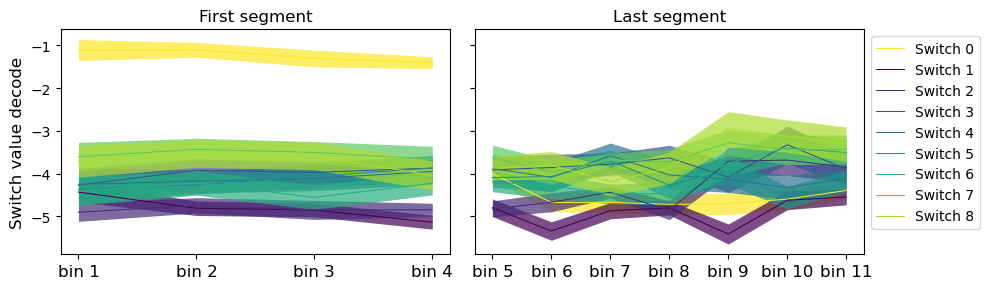

In [29]:
save_fig = False
if exchange_postswitch:
    plot_best_stem = True
else:
    plot_best_stem = from_best_stem
    
if incl_pause_time:
    num_bins_per_curve = np.array([4,7])  # Including reward/pause times
else:
    num_bins_per_curve = np.array([4,4]) # Not including reward/pause times

if plot_best_stem:
    mean_plot = mean_pred_beststem
    sem_plot = sem_pred_beststem
else:
    mean_plot = mean_pred_otherstem
    sem_plot = sem_pred_otherstem

peri_switch_ids = np.arange(-mean_plot.shape[0]+1,1,1)
if trial_alignment == 'trial_id_after_switch':
    peri_switch_ids = (-peri_switch_ids)[::-1] 

colormap = cm.viridis(np.linspace(0,1,mean_plot.shape[0]))
if trial_alignment == 'trial_id_after_switch':
    colormap = np.concatenate(([colormap[-1,:]],colormap[:-1,:]))
    
if DV == 'decision':
    yl = 'Decoded switch probability'
    fig_str = 'decoded_switchprob'
if DV == 'expected_value':
    yl = 'Expected value'
    fig_str = 'decoded_expval'  
if DV == 'past_value':
    yl = 'Past value'
    fig_str = 'decoded_pastval'
if DV == 'value_difference_max':
    yl = 'Switch value decode'
    fig_str = 'decoded_valdiffmax' 
if DV == 'value_difference_next':
    yl = 'Value difference next'
    fig_str = 'decoded_valdiffmaxnext' 
    
if plot_behavior:
    mean_plot = mean_hmm
    sem_plot = sem_hmm
    method = behav_model
    fig_str = 'valdiffmax'

x = np.arange(1,num_bins_per_curve.sum()+1,1) # x axis (bin numbers)
method = "LASSO" # Neural decoding results.
    
if bin_type == "patchprog" and not combine_bins:
    fig,axes = plt.subplots(3,2,figsize=(10,10),sharey=True)
    for i in range(mean_plot.shape[0]):
        axes[0][0].plot(x[:num_bins_per_curve[0]],mean_plot[i,:num_bins_per_curve[0]],\
                        color=colormap[i,:],linewidth=2,label=f'Switch {peri_switch_ids[i]}')
        axes[0][0].fill_between(x[:num_bins_per_curve[0]],mean_plot[i,:num_bins_per_curve[0]]-sem_plot[i,:num_bins_per_curve[0]],\
                                mean_plot[i,:num_bins_per_curve[0]]+sem_plot[i,:num_bins_per_curve[0]],color=colormap[i,:],alpha=0.7)
        axes[0][1].plot(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]],\
                        color=colormap[i,:],linewidth=2,label=f'Switch {peri_switch_ids[i]}')
        axes[0][1].fill_between(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]]-sem_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]],\
                                mean_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]]+sem_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]],color=colormap[i,:],alpha=0.7)
        axes[1][0].plot(x[:num_bins_per_curve[0]],mean_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]],\
                        color=colormap[i,:],linewidth=2,label=f'Switch {peri_switch_ids[i]}')
        axes[1][0].fill_between(x[:num_bins_per_curve[0]],mean_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]]-sem_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]],\
                                mean_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]]+sem_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]],color=colormap[i,:],alpha=0.7)
        axes[1][1].plot(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:num_bins_per_curve.sum()*2],color=colormap[i,:],linewidth=2,label=f'Trial {peri_switch_ids[i]}')
        axes[1][1].fill_between(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:num_bins_per_curve.sum()*2]-sem_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:num_bins_per_curve.sum()*2],\
                                mean_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:num_bins_per_curve.sum()*2]+sem_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:num_bins_per_curve.sum()*2],color=colormap[i,:],alpha=0.7)
        axes[2][0].plot(x[:num_bins_per_curve[0]],mean_plot[i,num_bins_per_curve.sum()*2:num_bins_per_curve.sum()*2+num_bins_per_curve[0]],\
                        color=colormap[i,:],linewidth=2,label=f'Switch {peri_switch_ids[i]}')
        axes[2][0].fill_between(x[:num_bins_per_curve[0]],mean_plot[i,num_bins_per_curve.sum()*2:num_bins_per_curve.sum()*2+num_bins_per_curve[0]]-sem_plot[i,num_bins_per_curve.sum()*2:num_bins_per_curve.sum()*2+num_bins_per_curve[0]],\
                                mean_plot[i,num_bins_per_curve.sum()*2:num_bins_per_curve.sum()*2+num_bins_per_curve[0]]+sem_plot[i,num_bins_per_curve.sum()*2:num_bins_per_curve.sum()*2+num_bins_per_curve[0]],color=colormap[i,:],alpha=0.7)
        axes[2][1].plot(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve.sum()*2+num_bins_per_curve[0]:],color=colormap[i,:],linewidth=2,label=f'Trial {peri_switch_ids[i]}')
        axes[2][1].fill_between(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve.sum()*2+num_bins_per_curve[0]:]-sem_plot[i,num_bins_per_curve.sum()*2+num_bins_per_curve[0]:],\
                                mean_plot[i,num_bins_per_curve.sum()*2+num_bins_per_curve[0]:]+sem_plot[i,num_bins_per_curve.sum()*2+num_bins_per_curve[0]:],color=colormap[i,:],alpha=0.7)

    axes[0][0].set_title('First leaf, stem A',size=12)
    axes[0][1].set_title('Last leaf, stem A',size=12)
    axes[1][0].set_title('First leaf, stem B',size=12)
    axes[1][1].set_title('Last leaf, stem B',size=12)
    axes[2][0].set_title('First leaf, stem C',size=12)
    axes[2][1].set_title('Last leaf, stem C',size=12)
    axes[0][0].set_xticks(x[:num_bins_per_curve[0]])
    axes[0][1].set_xticks(x[num_bins_per_curve[0]:])
    axes[1][0].set_xticklabels([f"bin {i}" for i in x[:num_bins_per_curve[0]]],ha="center",size=12)
    axes[1][0].set_xticks(x[:num_bins_per_curve[0]])
    axes[1][1].set_xticks(x[num_bins_per_curve[0]:])
    axes[1][1].set_xticklabels([f"bin {i}" for i in x[num_bins_per_curve[0]:]],ha="center",size=12)
    axes[2][0].set_xticks(x[:num_bins_per_curve[0]])
    axes[2][1].set_xticks(x[num_bins_per_curve[0]:])
    axes[2][0].set_xticklabels([f"bin {i}" for i in x[:num_bins_per_curve[0]]],ha="center",size=12)
    axes[2][1].set_xticklabels([f"bin {i}" for i in x[num_bins_per_curve[0]:]],ha="center",size=12)
    axes[0][0].set_ylabel(yl,size=12);
    axes[1][0].set_ylabel(yl,size=12);
    axes[2][0].set_ylabel(yl,size=12);
    axes[0][1].legend(bbox_to_anchor=(1,1));
    combination_str = '_threePatches'
else:
    if bin_type == "turn" and not combine_bins:
        # fig,axes = plt.subplots(2,2,figsize=(10,6),sharey=True)
        fig,axes = plt.subplots(2,2,figsize=(10,6))
        for i in range(mean_plot.shape[0]):
            axes[0][0].plot(x[:num_bins_per_curve[0]],mean_plot[i,:num_bins_per_curve[0]],\
                            color=colormap[i,:],linewidth=0.75,label=f'Trial {peri_switch_ids[i]}')
            axes[0][0].fill_between(x[:num_bins_per_curve[0]],mean_plot[i,:num_bins_per_curve[0]]-sem_plot[i,:num_bins_per_curve[0]],\
                                    mean_plot[i,:num_bins_per_curve[0]]+sem_plot[i,:num_bins_per_curve[0]],color=colormap[i,:],alpha=0.7)
            axes[0][1].plot(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]],\
                            color=colormap[i,:],linewidth=0.75,label=f'Trial {peri_switch_ids[i]}')
            axes[0][1].fill_between(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]]-sem_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]],\
                                    mean_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]]+sem_plot[i,num_bins_per_curve[0]:num_bins_per_curve[0]+num_bins_per_curve[1]],color=colormap[i,:],alpha=0.7)
            axes[1][0].plot(x[:num_bins_per_curve[0]],mean_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]],\
                            color=colormap[i,:],linewidth=0.75,label=f'Trial {peri_switch_ids[i]}')
            axes[1][0].fill_between(x[:num_bins_per_curve[0]],mean_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]]-sem_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]],\
                                    mean_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]]+sem_plot[i,num_bins_per_curve.sum():num_bins_per_curve.sum()+num_bins_per_curve[0]],color=colormap[i,:],alpha=0.7)
            axes[1][1].plot(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:],color=colormap[i,:],linewidth=2,label=f'Trial {peri_switch_ids[i]}')
            axes[1][1].fill_between(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:]-sem_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:],\
                                    mean_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:]+sem_plot[i,num_bins_per_curve.sum()*2-num_bins_per_curve[1]:],color=colormap[i,:],alpha=0.7)        
        
        axes[0][0].set_title('First segment, start left',size=12)
        axes[0][1].set_title('Last segment, start left',size=12)
        axes[1][0].set_title('First segment, start right',size=12)
        axes[1][1].set_title('Last segment, start right',size=12)
        axes[0][0].set_xticks(x[:num_bins_per_curve[0]])
        axes[0][1].set_xticks(x[num_bins_per_curve[0]:])
        axes[1][0].set_xticklabels([f"bin {i}" for i in x[:num_bins_per_curve[0]]],ha="center",size=12)
        axes[1][0].set_xticks(x[:num_bins_per_curve[0]])
        axes[1][1].set_xticks(x[num_bins_per_curve[0]:])
        axes[1][1].set_xticklabels([f"bin {i}" for i in x[num_bins_per_curve[0]:]],ha="center",size=12)
        axes[0][0].set_ylabel(yl,size=12);
        axes[1][0].set_ylabel(yl,size=12);
        axes[0][1].legend(bbox_to_anchor=(1,1));
        axes[0][0].set_ylim([-6,-1.2])
        axes[0][1].set_ylim([-6,-1.2])
        axes[1][0].set_ylim([-8,-1])
        axes[1][1].set_ylim([-8,-1])
        # axes[0, 0].sharey(axes[0, 1])  # Share y-axis for top row
        axes[1, 0].sharey(axes[1, 1])  # Share y-axis for bottom row
        combination_str = '_bothDir'
    else:
        # Progression-based decoder; or combining left/right turn results of the turn-based decoder; or combining patchA/B/C results of the patch-based decoder.
        fig,axes = plt.subplots(1,2,figsize=(10,3),sharey=True)
        for i in range(mean_plot.shape[0]):
            axes[0].plot(x[:num_bins_per_curve[0]],mean_plot[i,:num_bins_per_curve[0]],color=colormap[i,:],linewidth=0.75,label=f'Switch {peri_switch_ids[i]}')
            axes[0].fill_between(x[:num_bins_per_curve[0]],mean_plot[i,:num_bins_per_curve[0]]-sem_plot[i,:num_bins_per_curve[0]],mean_plot[i,:num_bins_per_curve[0]]+sem_plot[i,:num_bins_per_curve[0]],\
                                 color=colormap[i,:],alpha=0.7,linewidth=0)
            axes[1].plot(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve[0]:],color=colormap[i,:],linewidth=0.75,label=f'Switch {peri_switch_ids[i]}')
            axes[1].fill_between(x[num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve[0]:]-sem_plot[i,num_bins_per_curve[0]:],mean_plot[i,num_bins_per_curve[0]:]+sem_plot[i,num_bins_per_curve[0]:],\
                                 color=colormap[i,:],alpha=0.7,linewidth=0)
        axes[0].set_title('First segment',size=12)
        axes[1].set_title('Last segment',size=12)    
        axes[0].set_xticks(x[:num_bins_per_curve[0]])
        axes[0].set_xticklabels([f"bin {i}" for i in x[:num_bins_per_curve[0]]],ha="center",size=12)
        axes[1].set_xticks(x[num_bins_per_curve[0]:])
        axes[1].set_xticklabels([f"bin {i}" for i in x[num_bins_per_curve[0]:]],ha="center",size=12)
        axes[0].set_ylabel(yl,size=12);
        axes[1].legend(bbox_to_anchor=(1,1));

combination_str = ''
if combine_bins and bin_type=='turn':
    combination_str =  '_bothDirCombined'
if combine_bins and bin_type=='patchprog':
    combination_str =  '_allPatchCombined'
    
fig.tight_layout()
if save_fig:
    ###### Separate trials starting from the best vs. other stems:######
    if plot_best_stem:
        figname = file_name+f"_{fig_str}_{method}_{bin_type_str}bins_trials{peri_switch_ids[0]}to{peri_switch_ids[-1]}_from_beststem{combination_str}.pdf"
    else:
        figname = file_name+f"_{fig_str}_{method}_{bin_type_str}bins_trials{peri_switch_ids[0]}to{peri_switch_ids[-1]}_from_nonbeststem{combination_str}.pdf"          
    if one_poke_trial:
        if rewarded_one_poke:
            figname = figname[:-4]+'_one_poke_rewarded.pdf'
        else:
            figname = figname[:-4]+'_one_poke_unrewarded.pdf'
    else:
        if rewarded_switch_before_stay:
            figname = figname[:-4]+'_rewarded_first_trial.pdf'
        else:
            figname = figname[:-4]+'_unrewarded_first_trial.pdf'
    if exchange_postswitch:
        figname = figname[:-4]+'_post_switch_swapped.pdf'
    if normalize_DVs:
        figname = figname[:-4]+"_normalizedval.pdf"
    else:
        figname = figname[:-4]+"_unnormalizedval_rewardedswitchonly.pdf"
    if use_selected_sessions:
        figname = figname[:-4]+f"_r{''.join(str(int(n)) for n in sess)}.pdf"
    if train_with_selected_sessions:
        figname = figname[:-4]+f"_r{''.join(str(int(n)) for n in sess_train)}train+r{''.join(str(int(n)) for n in sess_test)}test.pdf"  
    if add_leaf:
        figname = figname[:-4]+"_addleaf.pdf"        
    plt.savefig(fig_dir+f"{behav_model}_value/"+figname, transparent = True, pad_inches=0.1)

### Bar plot of decoded value across peri-switch trials

In [460]:
####### NOTE: can only run this once for each dataset before plotting!!!!!!
if trial_alignment == 'trial_id_after_switch': # First row is switch trial, we want to move it to the bottom
    mean_pred_beststem = np.vstack((mean_pred_beststem[1:,:],mean_pred_beststem[0,:]))
    sem_pred_beststem = np.vstack((sem_pred_beststem[1:,:],sem_pred_beststem[0,:]))
    mean_pred_otherstem = np.vstack((mean_pred_otherstem[1:,:],mean_pred_otherstem[0,:]))
    sem_pred_otherstem = np.vstack((sem_pred_otherstem[1:,:],sem_pred_otherstem[0,:]))

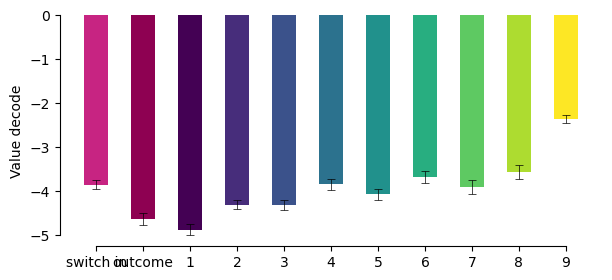

In [461]:
save_fig = False
use_first_bin = False
incl_outcome = True
no_periswitch = False
plot_best_stem = True # Make sure this is FALSE for one-poke plots
if plot_best_stem:
    stay_trial_idx = 6
    if np.isin(file_name,['senor20201114','senor20201116','peanut20201209']):
        stay_trial_idx = 5
else:
    stay_trial_idx = 4
    if np.isin(file_name,['senor20201114','senor20201116','peanut20201209']):
        stay_trial_idx = 3
    
if use_first_bin:
    if plot_best_stem:
        # means = np.concatenate(([mean_pred_otherstem[-1,4]],mean_pred_beststem[:-1,:4].mean(axis=1),[mean_pred_beststem[-1,0]])) # First bins of switch in & switch out, mean of pre-choice bins of stay trials
        means = np.concatenate(([mean_pred_otherstem[-1,4]],mean_pred_beststem[:-1,:4].mean(axis=1),[mean_pred_beststem[-1,3]])) # First bin of switch in, last bin of switch out, mean of pre-choice bins of stay trials
        sems = np.concatenate(([sem_pred_otherstem[-1,4]],sem_pred_beststem[:-1,:4].mean(axis=1),[sem_pred_beststem[-1,0]])) # First bins of switch in & switch out, mean of pre-choice bins of stay trials
        peri_switch_ids = np.arange(-mean_pred_beststem.shape[0]+1,1,1)
    else:    
        means = np.concatenate(([mean_pred_beststem[-1,4]],mean_pred_otherstem[:-1,:4].mean(axis=1),[mean_pred_otherstem[-1,0]]))
        sems = np.concatenate(([sem_pred_beststem[-1,4]],sem_pred_otherstem[:-1,:4].mean(axis=1),[sem_pred_otherstem[-1,0]]))
        peri_switch_ids = np.arange(-mean_pred_otherstem.shape[0]+1,1,1)
else:
    if plot_best_stem:
       ######### mean across bins
       if incl_outcome:
           # means = np.concatenate(([mean_pred_otherstem[-1,4:8].mean()],[mean_pred_otherstem[-1,8:].mean()],mean_pred_beststem[:-1,4:8].mean(axis=1),[mean_pred_beststem[-1,:4].mean()])) # Fig 5AC, Order: switch in (run), outcome, all stay trials(post-choice 4 bins), switch out.           
           # sems = np.concatenate(([sem_pred_otherstem[-1,4:8].mean()],[sem_pred_otherstem[-1,8:].mean()],sem_pred_beststem[:-1,4:8].mean(axis=1),[sem_pred_beststem[-1,:4].mean()]))   
           means = np.concatenate(([mean_pred_otherstem[-1,4:8].mean()],[mean_pred_otherstem[-1,8:].mean()],mean_pred_beststem[:,:4].mean(axis=1))) # Fig 4B, Order: switch in (run), outcome, stay trials (pre-choice 4 bins), switch out.           
           sems = np.concatenate(([sem_pred_otherstem[-1,4:8].mean()],[sem_pred_otherstem[-1,8:].mean()],sem_pred_beststem[:,:4].mean(axis=1)))       
       else: 
           means = np.concatenate(([mean_pred_otherstem[-1,4:8].mean()],mean_pred_beststem[:stay_trial_idx,4:8].mean(axis=1))) # Order: switch in (run), first 6 (or 5) stay trials(post-choice 4 bins).           
           sems = np.concatenate(([sem_pred_otherstem[-1,4:8].mean()],sem_pred_beststem[:stay_trial_idx,4:8].mean(axis=1)))                           
       peri_switch_ids = np.arange(-mean_pred_beststem.shape[0]+1,1,1)
    else:
       if incl_outcome:
            means = np.concatenate(([mean_pred_beststem[-1,4:8].mean()],[mean_pred_beststem[-1,8:].mean()],mean_pred_otherstem[:-1,4:8].mean(axis=1),[mean_pred_otherstem[-1,:4].mean()])) # Order: switch in (run), switch in (pause), stay trials(post-choice 4 bins), switch out.   
            sems = np.concatenate(([sem_pred_beststem[-1,4:8].mean()],[sem_pred_beststem[-1,8:].mean()],sem_pred_otherstem[:-1,4:8].mean(axis=1),[sem_pred_otherstem[-1,:4].mean()]))
           # means = np.concatenate(([mean_pred_beststem[-1,4:8].mean()],[mean_pred_beststem[-1,8:].mean()],mean_pred_otherstem[:,:4].mean(axis=1))) # Order: switch in (run), switch in (pause), stay trials (pre-choice 4 bins), switch out.        
            # sems = np.concatenate(([sem_pred_beststem[-1,4:8].mean()],[sem_pred_beststem[-1,8:].mean()],sem_pred_otherstem[:,:4].mean(axis=1)))           
       else:
            means = np.concatenate(([mean_pred_beststem[-1,-4:].mean()],mean_pred_otherstem[:,:4].mean(axis=1)))
            sems = np.concatenate(([sem_pred_beststem[-1,-4:].mean()],sem_pred_otherstem[:,:4].mean(axis=1)))           
       peri_switch_ids = np.arange(-mean_pred_otherstem.shape[0]+1,1,1)
if trial_alignment == 'trial_id_after_switch':
    peri_switch_ids = (-peri_switch_ids)[::-1]

if no_periswitch:
    categories = ['in','stay 1','out']
    colormap = np.vstack((cm.PiYG(np.linspace(0,1,10))[0,:],cm.viridis(np.linspace(0,1,means.shape[0]-2))[[0,-1]]))
else:
    if incl_outcome:
        colormap = np.vstack((cm.PiYG(np.linspace(0,1,10))[[1,0],:],cm.viridis(np.linspace(0,1,means.shape[0]-2))))
        categories = ['switch in']+['outcome']+[f'{i+1}' for i in peri_switch_ids]
        
    else:
        colormap = np.vstack((cm.PiYG(np.linspace(0,1,10))[[0],:],cm.viridis(np.linspace(0,1,means.shape[0]+2))))
        categories = ['switch in']+[f'{i+1}' for i in peri_switch_ids[:stay_trial_idx]]

if len(categories) > 8:
    plt.figure(figsize=(7, 3))
else:
    if len(categories) > 3:
        plt.figure(figsize=(5, 3))
    else:
        plt.figure(figsize=(1.5, 3))

if no_periswitch:
    plt.bar(categories, means[[0,2,means.shape[0]-1]], yerr=sems[[0,2,means.shape[0]-1]], capsize=3, color=colormap, width = 0.5, error_kw={'capthick': 0.5, 'elinewidth': 0.5}) # capsize adds horizontal lines to the error bars
else:
    plt.bar(categories, means, yerr=sems, capsize=3, color=colormap, width = 0.5, error_kw={'capthick': 0.5, 'elinewidth': 0.5}) # capsize adds horizontal lines to the error bars

plt.ylabel('Value decode')
sns.despine(trim=True,left=False)

if save_fig:
    method = 'LASSO'
    ###### Separate trials starting from the best vs. other stems:######
    if plot_best_stem:
        figname = file_name+f"_{method}_decoded_valdiffmax_{bin_type_str}bins_trials{peri_switch_ids[0]}to{peri_switch_ids[-1]}_from_beststem_barplot.pdf"
    else:
        figname = file_name+f"_{method}_decoded_valdiffmax_{bin_type_str}bins_trials{peri_switch_ids[0]}to{peri_switch_ids[-1]}_from_nonbeststem_barplot.pdf"
    if special_cases:
        if one_poke_trial:
            if rewarded_one_poke:
                figname = figname[:-4]+'_one_poke_rewarded.pdf'
            else:
                figname = figname[:-4]+'_one_poke_unrewarded.pdf'
        else:
            if rewarded_switch_before_stay:
                figname = figname[:-4]+'_rewarded_first_trial.pdf'
            else:
                figname = figname[:-4]+'_unrewarded_first_trial.pdf'
    if use_first_bin:
        figname = figname[:-4]+"_first_switch_bin.pdf"
    else:
        # figname = figname[:-4]+"_mean_switch_bins_postchoicestay1-6.pdf"
        figname = figname[:-4]+"_mean_switch_bins_in+stay1+out.pdf"
    if use_selected_sessions:
        figname = figname[:-4]+f"_r{''.join(str(int(n)) for n in sess)}.pdf"
    if add_leaf:
        figname = figname[:-4]+"_addleaf.pdf"
    print(f'saving {figname}')
    plt.savefig(fig_dir+f"{behav_model}_value/"+figname, transparent = True, pad_inches=0.1)

### Violin plot of decoded value across peri-switch trials
Use mean of stay-trial values calculated in the bar plot section above.

3045.0 0.49646499049977094


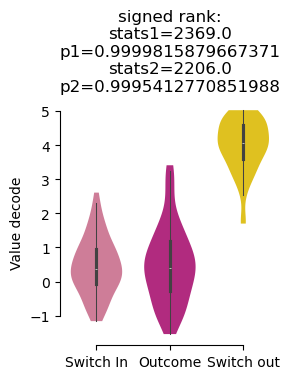

In [33]:
save_fig = False
keys_switchin = [f'bin {i} trial 0' for i in np.arange(5,9,1)] # Switch in 4 bins
keys_outcome = [f'bin {i} trial 0' for i in np.arange(9,12,1)] # Switch in outcome-period bins
keys_switchout = [f'bin {i} trial 0' for i in np.arange(1,5,1)] # Switch out 4 bins
if plot_best_stem :
    value_switchin = np.mean([y_pred_otherstem[k] for k in keys_switchin], axis=0)
    value_switchin_pause = np.mean([y_pred_otherstem[k] for k in keys_outcome], axis=0)
    value_switchout = np.mean([y_pred_beststem[k] for k in keys_switchout], axis=0)
else:
    value_switchin = np.mean([y_pred_beststem[k] for k in keys_switchin], axis=0)
    value_switchin_pause = np.mean([y_pred_beststem[k] for k in keys_outcome], axis=0)
    value_switchout = np.mean([y_pred_otherstem[k] for k in keys_switchout], axis=0)

# Subtract the first-stay switch value
value_switchin = value_switchin-means[2]
value_switchin_pause = value_switchin_pause-means[2]
value_switchout = value_switchout-means[2]

data = [value_switchin, value_switchin_pause, value_switchout]

fig, ax = plt.subplots(figsize=(3, 3))
sns.violinplot(
    data=data,
    palette=['palevioletred','mediumvioletred','gold'],  # custom colors per violin
    inner='box',                        # show box inside violin
    linewidth=0.5,                      # box size
    cut=0,                              # don't extend beyond data range
    width=0.7
)

for violin in ax.collections:
    violin.set_edgecolor('none')

sns.despine(trim=True,left=False)
ax.set_ylabel('Value decode')
# Label the x-axis
plt.xticks([0, 1, 2], ['Switch In', 'Outcome', 'Switch out'])
plt.tight_layout()
s1,p1 = wilcoxon(value_switchin,alternative='less')
s2,p2 = wilcoxon(value_switchin_pause,alternative='less')
s3,p3 = mannwhitneyu(value_switchin,value_switchin_pause,alternative='greater')
print(s3,p3)
plt.title(f'signed rank:\nstats1={s1}\np1={p1}\nstats2={s2}\np2={p2}')
if save_fig:
    method = 'LASSO'
    if plot_best_stem:
        figname = file_name+f"_{method}_decoded_valdiffmax_switchin+pause+switchout_from_beststem.pdf"
    else:
        figname = file_name+f"_{method}_decoded_valdiffmax_switchin+pause+switchout_from_nonbeststem.pdf"
    plt.savefig(fig_dir+f"{behav_model}_value/"+figname, transparent = True, pad_inches=0.1)

### Neural value depletion: first-stay switch value - switch-in value

#### Use mean of stay-trial values calculated in the bar plot section above (do this for each animal separately)

In [34]:
if np.isin(file_name,['j1620210714','wilbur20210404','peanut20201203','senor20201109']):
    value_deplete_early = -value_switchin
    print(value_deplete_early.shape)
else:
    if np.isin(file_name,['j1620210718','wilbur20210408','peanut20201208','senor20201113']):
        value_deplete_late = -value_switchin
    else:
        value_deplete_late = np.concatenate((value_deplete_late,-value_switchin))
    print(value_deplete_late.shape)

(78,)


### Violin plot of neural value repletion/depletion across early and late days (including plotting switch-in value reset for each animal)


#### Plot each animal

saving /stelmo/xulu/preliminary_plots/betalik_value/ratW_neural_value_replete_early_and_late_days_highval_patch_postswitch_vs_earlystay_diff_individualTrials_allswitches_rewardedswitch_addleaf.pdf


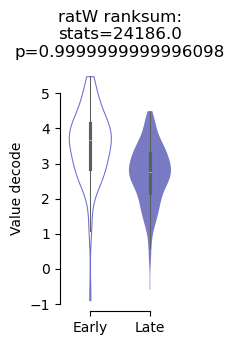

In [406]:
save_fig = True
colormap1 = cm.tab20b(np.linspace(0,1,20))
colormap2 = cm.tab20(np.linspace(0,1,20))
colorplot= np.concatenate((colormap1[[14,2,18],:],colormap2[[-2],:]))
animals = ['J','W','S','P']
# data = [value_deplete_early, value_deplete_late]
data = [value_replete_early, value_replete_late]

fig, ax = plt.subplots(figsize=(2, 3))
sns.violinplot(
    data=data,
    palette=['white',colorplot[animals.index(file_name[0].upper())]],  # custom colors per violin
    inner='box',                        # show box inside violin
    linewidth=0.5,                      # box size
    cut=0,                              # don't extend beyond data range
    width=0.7
)

bodies = [c for c in ax.collections if isinstance(c, PolyCollection)][:2]
bodies[0].set_facecolor("white")
bodies[0].set_edgecolor(colorplot[animals.index(file_name[0].upper())])
bodies[0].set_linewidth(0.75)
bodies[1].set_edgecolor("none")

sns.despine(trim=True,left=False)
ax.set_ylabel('Value decode')
# Label the x-axis
plt.xticks([0, 1], ['Early', 'Late'])
plt.tight_layout()
s,p = mannwhitneyu(data[0],data[1],alternative='less')
# s,p = mannwhitneyu(data[0],data[1],alternative='two-sided')

plt.title(f'rat{file_name[0].upper()} ranksum:\nstats={s}\np={p}')
if save_fig:
    method = 'LASSO'
    # figname = fig_dir+f"{behav_model}_value/"+f"rat{file_name[0].upper()}_neural_value_deplete_early_and_late_days_highval_patch_postswitch_vs_earlystay_diff_individualTrials_rewardedswitch.pdf"
    figname = fig_dir+f"{behav_model}_value/"+f"rat{file_name[0].upper()}_neural_value_replete_early_and_late_days_highval_patch_postswitch_vs_earlystay_diff_individualTrials_allswitches.pdf"
    if add_leaf:
        figname = figname[:-4]+"_rewardedswitch_addleaf.pdf"
    print(f'saving {figname}')
    plt.savefig(figname, transparent = True) # Compare value predict of post-switch bins to the mean of early-stay trials


In [125]:
# Check whether day 1 resetting is significanlty greater than 0.
s_e,p_e = wilcoxon(value_deplete_early,alternative='greater')
s_l,p_l = wilcoxon(value_deplete_late,alternative='greater')
print(p_e,p_l)

0.0001330327484977137 1.5767367850620582e-36


### Dot plot with error bars of decoded value following reward vs. omission
(1) rewarded & unrewarded switch before stay; (2) rewarded & unrewarded single-visit trials

In [237]:
pause_bins = [f'bin {i} trial 0' for i in [9,10,11]]
plot_best_stem = True

if one_poke_trial:
        switch_in_value = [y_pred_rewarded_best['bin 8 trial 0'],y_pred_unrewarded_best['bin 8 trial 0']] # Last bin of the single poke switch in
        pause_value = [np.mean(np.stack([y_pred_rewarded_best[k] for k in pause_bins], axis=0), axis=0),np.mean(np.stack([y_pred_unrewarded_best[k] for k in pause_bins], axis=0), axis=0)]
        switch_out_value = [y_pred_rewarded_nonbest['bin 1 trial 0'],y_pred_unrewarded_nonbest['bin 1 trial 0']] # Switch after the single poke
        stem_str = "from_nonbeststem"
else:
    if plot_best_stem:
        # High-rew patch, rewarded and unrewarded cases
        switch_in_value = [y_pred_rewarded_nonbest['bin 8 trial 0'],y_pred_unrewarded_nonbest['bin 8 trial 0']]
        pause_value = [np.mean(np.stack([y_pred_rewarded_nonbest[k] for k in pause_bins], axis=0), axis=0),np.mean(np.stack([y_pred_unrewarded_nonbest[k] for k in pause_bins], axis=0), axis=0)]
        first_stay_value = [y_pred_rewarded_best['bin 1 trial 1'],y_pred_unrewarded_best['bin 1 trial 1']]
        stem_str = "from_beststem"
    else:
        # Lower-rew patches, rewarded and unrewarded cases
        switch_in_value = [y_pred_rewarded_best['bin 8 trial 0'],y_pred_unrewarded_best['bin 8 trial 0']]
        pause_value = [np.mean(np.stack([y_pred_rewarded_best[k] for k in pause_bins], axis=0), axis=0),np.mean(np.stack([y_pred_unrewarded_best[k] for k in pause_bins], axis=0), axis=0)]
        first_stay_value = [y_pred_rewarded_nonbest['bin 1 trial 1'],y_pred_unrewarded_nonbest['bin 1 trial 1']]
        stem_str = "from_nonbeststem"
    

In [238]:
def dotplot_three_pairs_with_ci(
    switch_in_value, pause_value, first_updated_value,
    metric_labels=("Switch in", "Pause", "Stay 1"),
    cond_labels=("Rewarded", "Unrewarded"),
    colors=("firebrick", "royalblue"),
    offsets=(+0.1, -0.1),           # horizontal offsets for the two conditions
    hollow_unrewarded=False,
    point_size=80, capsize=6,
    save_name=""
):
    """
    Each input is a list/tuple: [rewarded_array, unrewarded_array].
    Arrays can be different sizes.
    """
    metrics = [switch_in_value, pause_value, first_updated_value]
    x_base = np.arange(3)

    # collect stats: means and 95% CIs
    stats = {cond: {"x": [], "y": [], "lo": [], "hi": []} for cond in cond_labels}
    for j, (metric, label) in enumerate(zip(metrics, metric_labels)):
        rewarded, unrewarded = metric
        m_r, lo_r, hi_r = bootstrap_mean_ci(rewarded)
        m_u, lo_u, hi_u = bootstrap_mean_ci(unrewarded)

        stats[cond_labels[0]]["x"].append(x_base[j] + offsets[0])
        stats[cond_labels[0]]["y"].append(m_r)
        stats[cond_labels[0]]["lo"].append(lo_r)
        stats[cond_labels[0]]["hi"].append(hi_r)

        stats[cond_labels[1]]["x"].append(x_base[j] + offsets[1])
        stats[cond_labels[1]]["y"].append(m_u)
        stats[cond_labels[1]]["lo"].append(lo_u)
        stats[cond_labels[1]]["hi"].append(hi_u)

    fig, ax = plt.subplots(figsize=(5, 3))

    # plot each condition: error bars + points + connecting line
    for c_idx, cond in enumerate(cond_labels):
        xs = np.array(stats[cond]["x"], float)
        ys = np.array(stats[cond]["y"], float)
        los = np.array(stats[cond]["lo"], float)
        his = np.array(stats[cond]["hi"], float)

        yerr = np.vstack([ys - los, his - ys])

        # style of plotting for the unrewarded condition
        if hollow_unrewarded and cond == "Unrewarded":
            mfc, mec, mew, marker = 'none', colors[c_idx], 1.6, 'o'
        else:
            mfc, mec, mew, marker = colors[c_idx], 'none', 0.5, 'o'

        ax.errorbar(
            xs, ys, yerr=yerr,
            fmt=marker, markersize=np.sqrt(point_size),  # match scatter size
            mfc=mfc, mec=mec, mew=mew,
            color=colors[c_idx], ecolor=colors[c_idx],
            elinewidth=0.5, capsize=capsize, capthick=0.5,
            linestyle='none', zorder=3
        )

        # connecting line through the three metric points
        ax.plot(xs, ys, color=colors[c_idx], alpha=0.7, linewidth=0.5)

    # cosmetics
    ax.set_xticks(x_base)
    ax.set_xticklabels(metric_labels)
    ax.set_xlabel("")
    ax.set_ylabel("Switch value decode")
    ax.set_xlim(-0.6, 2.6)

    # legend
    from matplotlib.lines import Line2D
    handles = []
    # rewarded (filled)
    handles.append(Line2D([0],[0], marker='o', linestyle='-', color=colors[0],
                          markerfacecolor=colors[0], markeredgecolor='none',
                          label=cond_labels[0]))
    # unrewarded (hollow, if chosen)
    if hollow_unrewarded:
        handles.append(Line2D([0],[0], marker='o', linestyle='-', color=colors[1],
                              markerfacecolor='none', markeredgecolor=colors[1],
                              label=cond_labels[1]))
    else:
        handles.append(Line2D([0],[0], marker='o', linestyle='-', color=colors[1],
                              markerfacecolor=colors[1], markeredgecolor='none',
                              label=cond_labels[1]))
    ax.legend(handles=handles, frameon=False, ncol=1, loc="best")
    plt.tight_layout()
    sns.despine(trim=True,left=False);

    if len(save_name) != 0:
         plt.savefig(save_name, transparent = True)
        
    return ax

#### Plot rewarded & unrewarded switch in + subsequent first stay

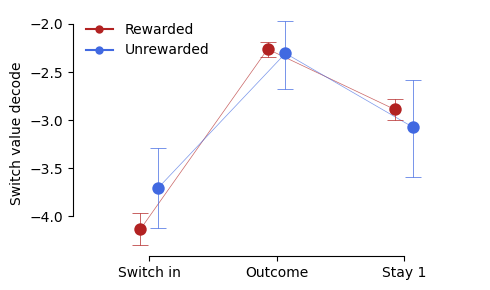

In [239]:
save_fig = True
figname = ""
if save_fig:
    figname = fig_dir+f"{behav_model}_value/"+f'{file_name}_LASSO_decoded_valdiffmax_{bin_type_str}bins_switchtrials_{stem_str}_rewarded_unrewarded_dotplot.pdf'
ax = dotplot_three_pairs_with_ci(
    switch_in_value, pause_value, first_stay_value,
    offsets=(-0.07, +0.07),
    metric_labels=("Switch in", "Outcome", "Stay 1"),
    cond_labels=("Rewarded", "Unrewarded"), 
    save_name = figname
)

#### Plot rewarded & unrewarded single-visit trials + subsequent switch-out

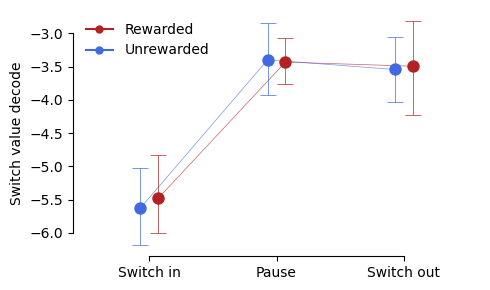

In [29]:
save_fig = True
figname = ""
if save_fig:
    figname = fig_dir+f"{behav_model}_value/"+f'{file_name}_LASSO_decoded_valdiffmax_{bin_type_str}bins_singlepokes_{stem_str}_rewarded_unrewarded_dotplot.pdf'
ax = dotplot_three_pairs_with_ci(
    switch_in_value, pause_value, switch_out_value,
    offsets=(+0.07, -0.07),
    metric_labels=("Switch in", "Pause", "Switch out"),
    cond_labels=("Rewarded", "Unrewarded"), 
    save_name = figname
)

## 4. Value update or neural state shifts after reward vs. omission

### Dot plot with error bars of value update difference following reward vs. no reward
!!!!!! Note that this section uses the big dataframes created for the linear-mixed effect of Reward:IsEarlySess in the statistical test section !!!!!!

In [146]:
# Load saved big dataframes:
value_update_best_allrats = pd.read_pickle(results_dir+f"{behav_model}_value/"+'j16+wilbur+senor+peanut_neural_value_update_rewarded_unrewarded_beststem_mixedlinear_early_late_days.pkl')
value_update_nonbest_allrats = pd.read_pickle(results_dir+f"{behav_model}_value/"+'j16+wilbur+senor+peanut_neural_value_update_rewarded_unrewarded_nonbeststem_mixedlinear_early_late_days.pkl')


In [79]:
def bootstrap_diff_means(x0, x1, n_boot=10000, alpha=0.05, rng=None):
    """
    Bootstrap the difference of means: mean(x0) - mean(x1).
    x0 = Reward==0 samples; x1 = Reward==1 samples.
    Returns point_estimate (sample diff), low, high (percentile CI).
    """
    x0 = np.asarray(x0, dtype=float)
    x1 = np.asarray(x1, dtype=float)

    pe = x0.mean() - x1.mean()

    if rng is None:
        rng = np.random.default_rng(0) # Use a default seed number to make the results replicable.
    b0 = rng.choice(x0, size=(n_boot, len(x0)), replace=True).mean(axis=1)
    b1 = rng.choice(x1, size=(n_boot, len(x1)), replace=True).mean(axis=1)
    bdiff = b0 - b1
    lo, hi = np.quantile(bdiff, [alpha/2, 1 - alpha/2])
    return pe, lo, hi

def plot_value_update_diff_by_animal(
    df,
    n_boot=10000,
    alpha=0.05,
    seed=0,
    jitter=0.09,
    point_size=70,
    colors=None,
    early_marker='o',
    late_marker='s',
    var_name="ValueDiff",
    save_name=""
):
    """
    df: DataFrame with columns ['Animal','IsEarlySess','Reward','ValueDiff'].
    Plots two columns: Early (IsEarlySess=1) vs Late (IsEarlySess=0),
    with one jittered dot per animal in each column showing:
        mean(ValueDiff|R=0) - mean(ValueDiff|R=1),
    plus 95% bootstrap CI. Dots are colored per animal.
    """
    req = {"Animal","IsEarlySess","Reward",var_name}
    if not req.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns {req}")

    animal_ids = df["Animal"].unique().astype(int)
    animals = ['j16','wilbur','senor','peanut']
    rng = np.random.default_rng(seed)

    # color per animal
    colormap1 = cm.tab20b(np.linspace(0,1,20))
    colormap2 = cm.tab20(np.linspace(0,1,20))
    colors= np.concatenate((colormap1[[14,2,18],:],colormap2[[-2],:]))
    
    # Compute per-animal diffs + CIs for Early and Late
    stats = {1: {}, 0: {}}  # {IsEarlySess: {animal: (y, lo, hi)}}
    for i in range(len(animal_ids)):
        for sess in (1, 0):
            dsub = df[(df["Animal"] == animal_ids[i]) & (df["IsEarlySess"] == sess)]
            x0 = dsub.loc[dsub["Reward"] == 0, var_name].values
            x1 = dsub.loc[dsub["Reward"] == 1, var_name].values
            y, lo, hi = bootstrap_diff_means(x0, x1, n_boot=n_boot, alpha=alpha, rng=rng)
            stats[sess][i] = (y, lo, hi) # Note that sess = 1 is early day

    # Plot: two columns at x=0 (Early) and x=1 (Late)
    ####### TODO: make the following a general plotting function and then call this function within each specific plotting function.########
    fig, ax = plt.subplots(figsize=(3, 4))
    xpos = {1: 0.0, 0: 1.0}
    
    for i in range(len(animal_ids)):
        # Early days:
        y1, lo1, hi1 = stats[1][i]
        x1 = xpos[1] + rng.normal(0, jitter)
        yerr = np.vstack([y1 - lo1, hi1 - y1])
        ax.errorbar(
            x1, y1, yerr=yerr,
            fmt=early_marker, markersize=np.sqrt(point_size),
            mfc=colors[i], mec='none', mew=0.5,
            color=colors[i], ecolor=colors[i],
            elinewidth=0.5, capsize=6, capthick=1.6, zorder=3
        )
        y2, lo2, hi2 = stats[0][i]
        x2 = xpos[0] + rng.normal(0, jitter)
        yerr = np.vstack([y2 - lo2, hi2 - y2])
        ax.errorbar(
            x2, y2, yerr=yerr,
            fmt=late_marker, markersize=np.sqrt(point_size),
            mfc=colors[i], mec='none', mew=0.5,
            color=colors[i], ecolor=colors[i],
            elinewidth=0.5, capsize=6, capthick=1.6, zorder=3
        )
        ax.plot([x1, x2], [y1, y2], color='gray', alpha=0.6, linewidth=0.5)
        
    ax.set_xticks([xpos[1], xpos[0]])
    ax.set_xticklabels(["Early", "Late"])
    if var_name=="ValueDiff":
        # ax.set_ylabel("mean(ValueDiff|R=0) − mean(ValueDiff|R=1)")
        ax.set_ylabel("Switch value update\n unrewarded vs. rewarded")
    if var_name=="ValueDiffOutcome":
        ax.set_ylabel("Switch value outcome effect\n unrewarded vs. rewarded")
    ax.axhline(0, color='gray',linestyle='--',lw=0.25, alpha=0.4) # zero reference
    ax.set_xlim(-0.6, 1.6)
    
    handles = [
        Line2D([0],[0], marker='o', linestyle='None', color='none',
               markerfacecolor=colors[i], markeredgecolor='none', label=f"Rat {animals[i][0].upper()}")
        for i in range(len(animal_ids))
    ]
    leg = ax.legend(handles=handles, frameon=False, ncol=1,
                    loc="best")               

    fig.tight_layout()
    sns.despine(trim=True,left=False)

    if len(save_name) != 0:
         plt.savefig(save_name, transparent = True)
    
    return ax


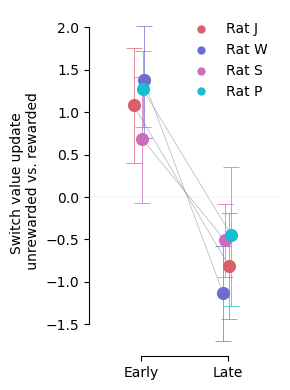

In [85]:
save_fig = True
plot_best_stem = True
figname = ""
var_name="ValueDiff"
# var_name="ValueDiffOutcome"
if save_fig:
    if var_name=="ValueDiff":
        figname = fig_dir+f"{behav_model}_value/"+f"j16+wilbur+senor+peanut_neural_value_update_diff_postreward_vs_noreward_beststem_early_and_late_days_dotplot.pdf"
        # figname = fig_dir+f"{behav_model}_value/"+f"j16+wilbur+senor+peanut_neural_value_update_diff_postreward_vs_noreward_nonbeststem_early_and_late_days_dotplot.pdf"
    if var_name=="ValueDiffOutcome":
        figname = fig_dir+f"{behav_model}_value/"+f"j16+wilbur+senor+peanut_neural_value_outcome_update_postreward_vs_noreward_beststem_early_and_late_days_dotplot.pdf"
        # figname = fig_dir+f"{behav_model}_value/"+f"j16+wilbur+senor+peanut_neural_value_outcome_update_postreward_vs_noreward_nonbeststem_early_and_late_days_dotplot.pdf"

if plot_best_stem:
    ax = plot_value_update_diff_by_animal(value_update_best_allrats, n_boot=10000, alpha=0.05, seed=0, point_size=90, jitter=0.07, early_marker='o', late_marker='o', var_name=var_name,save_name=figname)
else:
    ax = plot_value_update_diff_by_animal(value_update_nonbest_allrats, n_boot=10000, alpha=0.05, seed=0, point_size=90, jitter=0.07, early_marker='o', late_marker='o', var_name=var_name,save_name=figname)

# print(summary)


### Dot plot with error bars of value update following rewarded vs. unrewarded single visits
!!!!!! Note that this section uses the big dataframes for single-visit trials created in a previous section !!!!!!

In [20]:
# Load the big one-poke dataframes
behav_model = 'betalik'
value_update_onepoke_allrats = pd.read_pickle(results_dir+f"{behav_model}_value/"+'j16+wilbur+sernor+peanut_neural_value_metric_rewarded_unrewarded_onepokes.pkl')


In [66]:
def plot_value_metric_grouped_by_conditions(
    df,
    value_metric,
    cond="Reward",
    add_reference=True,
    connect_pairs=False,
    n_boot=10000,
    alpha=0.05,
    seed=0,
    jitter=0.07,
    point_size=70,
    save_name=""
):
    """
    df: pandas DataFrame with columns ['Animal',cond,value_metric(s)].
    Makes two columns of dot plots:
        - Column 0: cond == 1, each dot is an Animal's mean(ValueDiff) with 95% bootstrap CI
        - Column 1: cond == 0, same
    Returns (ax, summary_df).
    """
    required = {"Animal", cond, value_metric}
    if not required.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns {required}")

    rng = np.random.default_rng(seed)

    animal_ids = df["Animal"].unique().astype(int)
    animals = ['j16','wilbur','senor','peanut']
    
    # color per animal
    colormap1 = cm.tab20b(np.linspace(0,1,20))
    colormap2 = cm.tab20(np.linspace(0,1,20))
    colors= np.concatenate((colormap1[[14,2,18],:],colormap2[[-2],:]))
    
    # compute mean + bootstrap CI for each Animal within each condition
    rows = []
    for (a, r), dsub in df.groupby(["Animal", cond], sort=True):
        m, lo, hi = bootstrap_mean_ci(dsub[value_metric].values, n_boot=n_boot, alpha=alpha, seed=0)
        rows.append({"Animal": a, cond: r, "Mean": m, "CI_low": lo, "CI_high": hi, "n": len(dsub)})

    summary = pd.DataFrame(rows).sort_values([cond, "Animal"])
    
    # Plot: two columns at x=0 (Early) and x=1 (Late)
    fig, ax = plt.subplots(figsize=(3, 4))
    xpos = {1: 0.0, 0: 1.0}  # left: cond == 1, right: cond == 0

    for i in range(len(animal_ids)):
        x_pair = dict()
        y_pair = dict()
        for r in (1, 0):
            row = summary[(summary["Animal"] == animal_ids[i]) & (summary[cond] == r)]
            x = xpos[r] + rng.normal(0, jitter)
            y = row["Mean"].values[0]
            lo = row["CI_low"].values[0]
            hi = row["CI_high"].values[0]
            yerr = np.vstack([y - lo, hi - y])
            x_pair[r] = x
            y_pair[r] = y

            ax.errorbar(
                x, y, yerr=yerr,
                fmt='o', markersize=np.sqrt(point_size),
                mfc=colors[i], mec='none', mew=0.5,
                color=colors[i], ecolor=colors[i],
                elinewidth=0.5, capsize=6, capthick=1.6, zorder=3
            )
        if connect_pairs:
            ax.plot([x_pair[1], x_pair[0]], [y_pair[1], y_pair[0]], color='gray', alpha=0.6, linewidth=0.5)
            
    if add_reference:
        ax.axhline(0, color='k',linestyle='--',lw=0.5, alpha=0.7) # zero reference
    ax.set_xticks([xpos[1], xpos[0]])
    if cond == "Reward":
        ax.set_xticklabels(["Rewarded", "Unrewarded"])
    if cond == "IsStay":
        ax.set_xticklabels(["Stay 1", "Switch"])
    if value_metric == "ValueDiff":
        ax.set_ylabel("Switch value update")
    if value_metric == "RelativeValue":
        ax.set_ylabel("Value relative to stay")
    if value_metric == "Value":
        ax.set_ylabel("Decoded switch value")
    ax.set_xlim(-0.6, 1.6)
    # ax.set_ylim(-6,-1.5)

    handles = [
        Line2D([0],[0], marker='o', linestyle='None', color='none',
               markerfacecolor=colors[i], markeredgecolor='none', label=f"Rat {animals[i][0].upper()}")
        for i in range(len(animal_ids))
    ]
    leg = ax.legend(handles=handles, frameon=False, ncol=1,
                    loc="best")

    fig.tight_layout()
    sns.despine(trim=True,left=False)

    if len(save_name) != 0:
         plt.savefig(save_name, transparent = True)
        
    return ax, summary

Rewarded one pokes (>0): stats = 9454.0, pval = 6.895566820438478e-16
Unrewarded one pokes (>0): stats = 5515.0, pval = 1.0371417177191131e-13


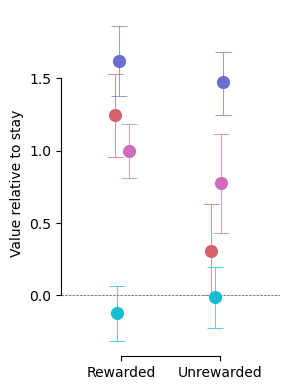

In [67]:
save_fig = True
figname = ""
# metric_name = "ValueDiff"
metric_name = "RelativeValue"
if save_fig:
    if metric_name == "ValueDiff":
        save_metric = "neural_value_update"
    if metric_name == "RelativeValue":
        save_metric = "value_relative_to_stay"
    figname = fig_dir+f"{behav_model}_value/"+f"j16+wilbur+senor+peanut_{save_metric}_rewarded_unrewarded_onepokes_9days_dotplot.pdf"

ax, summary = plot_value_metric_grouped_by_conditions(value_update_onepoke_allrats, value_metric=metric_name, point_size=90, n_boot=10000, alpha=0.05, jitter=0.07, seed=5, save_name=figname)
# print(summary.head())
s_r,p_r = wilcoxon(value_update_onepoke_allrats[value_update_onepoke_allrats.Reward==1][metric_name],alternative='Greater')
s_ur,p_ur = wilcoxon(value_update_onepoke_allrats[value_update_onepoke_allrats.Reward==0][metric_name],alternative='Greater')
print(f'Rewarded one pokes (>0): stats = {s_r}, pval = {p_r}\nUnrewarded one pokes (>0): stats = {s_ur}, pval = {p_ur}')

In [68]:
# Compare whether rewarded and unrewarded cases differ.
mannwhitneyu(value_update_onepoke_allrats[value_update_onepoke_allrats.Reward==1][metric_name],\
             value_update_onepoke_allrats[value_update_onepoke_allrats.Reward==0][metric_name],alternative='two-sided')

MannwhitneyuResult(statistic=7885.0, pvalue=0.8053820765105605)

In [52]:
# Mixed-effects model across all animals (random intercept per animal):
# ValueDiff ~ Reward  → effects of Reward
# (1 | Animal)  → random intercept per Animal

model = smf.mixedlm(
    "ValueDiff ~ Reward",
    # "RelativeValue ~ Reward",
    data=value_update_onepoke_allrats,
    groups=value_update_onepoke_allrats["Animal"]
)
result = model.fit()
print(result.summary())
print(result.params)             # estimates (fixed + variance params)
print(result.pvalues)            # p-values for fixed-effect coefficients


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ValueDiff
No. Observations: 262     Method:             REML     
No. Groups:       4       Scale:              1.6368   
Min. group size:  42      Log-Likelihood:     -441.7342
Max. group size:  97      Converged:          Yes      
Mean group size:  65.5                                 
--------------------------------------------------------
           Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  0.636     0.314  2.025  0.043   0.020   1.252
Reward     0.190     0.163  1.165  0.244  -0.130   0.511
Group Var  0.333     0.234                              

Intercept    0.636363
Reward       0.190434
Group Var    0.203651
dtype: float64
Intercept    0.042870
Reward       0.243953
Group Var    0.265565
dtype: float64


### Dot plot with error bars of initial state shift angles after reward vs omission (post LFADS)

In [619]:
# Load the neural shift angles in early and late sessions for each animal.
behav_model = 'betalik'
sessions = {'j16':['j1620210714','j1620210718','j1620210719'], 'wilbur':['wilbur20210404','wilbur20210408','wilbur20210409','wilbur20210410'],\
            'senor':['senor20201109','senor20201114','senor20201116'],'peanut':['peanut20201203','peanut20201208','peanut20201209']}

cosine_angle_allrats = dict()
cosine_angle_CI_allrats = dict()
for animal in sessions.keys():
    PCs = [1,2]
    for file_name in sessions[animal]:
        if np.isin(file_name,['j1620210714','wilbur20210404','senor20201109','peanut20201203']):
            cosine_angle = []
            cosine_angle_CI = []
        if file_name == 'j1620210719':
            PCs = [1,3]
        if np.isin(file_name,['peanut20201208','peanut20201209']):
            PCs = [2,3]
        file_path = results_dir+f"{file_name}_cosine_angle_between_initial_state_shifts_reward_vs_omission_PCs{PCs[0]+1}{PCs[1]+1}.npz"
        if np.isin(file_name, ['wilbur20210409','senor20201114','senor20201116']):
            file_path = file_path[:-4]+'_r1234.npz'
        if file_name == 'j1620210719':
            file_path = file_path[:-4]+'_r1345.npz'
        if file_name == 'peanut20201208':
            file_path = file_path[:-4]+'_r1235.npz'
        a = np.load(file_path,allow_pickle=True)
        cosine_angle.append(np.array(a.f.boot_cos_pcs))
        cosine_angle_CI.append(a.f.ci_cos_pcs)
    cosine_angle_allrats[animal] = cosine_angle
    cosine_angle_CI_allrats[animal] = cosine_angle_CI


In [620]:
def _mean_ci(x: np.ndarray) -> Tuple[float, float, float]:
    """Compute mean and 95% CI (2.5th, 97.5th percentiles)."""
    x = np.asarray(x, dtype=float)
    m = np.nanmean(x)
    lo, hi = np.nanpercentile(x, [2.5, 97.5])
    return float(m), float(lo), float(hi)


def plot_bootstrap_groups_by_animal(
    boots: Mapping[str, Mapping[str, np.ndarray]],
    *,
    jitter: float = 0.08,
    seed: int = 0,
    connect_with_gray: bool = True,
    annotate_delta_ci: bool = True,
    figsize: Tuple[float, float] = (5.0, 4.2),
    point_size = 60,
    fig_name = "",
) -> Tuple[plt.Figure, plt.Axes, Dict[str, Dict[str, Any]]]:
    """
    Plot early vs late cosine bootstrap means + 95% CI for multiple animals.

    For each animal, also computes the bootstrap delta:
        boot_delta = boot_late - boot_early
    and reports its 95% CI.

    Parameters
    ----------
    boots
        Dict: animal_id -> {"early": (n_boot,), "late": (n_boot,)}.
    jitter
        Horizontal jitter (x-axis units).
    seed
        RNG seed for reproducible jitter.
    connect_with_gray
        If True, draw gray lines connecting early and late points per animal.
    annotate_delta_ci
        If True, annotate delta CI above the late point for each animal.
    """
    rng = np.random.default_rng(seed)
    animals = list(boots.keys())
    n_animals = len(animals)

    # color per animal
    colormap1 = cm.tab20b(np.linspace(0,1,20))
    colormap2 = cm.tab20(np.linspace(0,1,20))
    colors= np.concatenate((colormap1[[14,2,18],:],colormap2[[-2],:]))

    # Jitter offsets between points
    offsets = np.linspace(-jitter, jitter, n_animals) if n_animals > 1 else np.array([0.0])

    x_early_base = 0.0
    x_late_base = 0.7

    fig, ax = plt.subplots(figsize=figsize)
    stats_by_animal: Dict[str, Dict[str, Any]] = {}

    for i, animal in enumerate(animals):
        b_early = np.asarray(boots[animal]["early"], dtype=float)
        b_late = np.asarray(boots[animal]["late"], dtype=float)

        if b_early.shape != b_late.shape:
            raise ValueError(
                f"{animal}: early and late bootstrap arrays must have same shape; "
                f"got {b_early.shape} vs {b_late.shape}"
            )

        # Bootstrap delta (paired by iteration)
        boot_delta = b_late - b_early

        # Summary statistics
        m_e, lo_e, hi_e = _mean_ci(b_early)
        m_l, lo_l, hi_l = _mean_ci(b_late)
        m_d, lo_d, hi_d = _mean_ci(boot_delta)

        # Store stats
        stats_by_animal[animal] = {
            "early_mean": m_e,
            "early_ci": (lo_e, hi_e),
            "late_mean": m_l,
            "late_ci": (lo_l, hi_l),
            "delta_mean": m_d,
            "delta_ci": (lo_d, hi_d),
            "n_boot": int(len(boot_delta)),
        }

        # Asymmetric CI errorbars
        yerr_e = np.array([[m_e - lo_e], [hi_e - m_e]])
        yerr_l = np.array([[m_l - lo_l], [hi_l - m_l]])

        # Jittered x positions
        x_e = x_early_base + offsets[i]
        x_l = x_late_base + offsets[i]

        # Gray connecting line between groups
        if connect_with_gray:
            ax.plot([x_e, x_l], [m_e, m_l], color="gray", alpha=0.7, linewidth=1.0)

        # Plot early / late points
        c = colors[i,:]
        ax.errorbar(x_e, m_e, yerr=yerr_e, markersize=np.sqrt(point_size), fmt="o", capsize=6, mfc=c, elinewidth=1, mec='none', mew=0.5, color=c, ecolor=c, capthick=1, zorder=3)
        ax.errorbar(x_l, m_l, yerr=yerr_l, markersize=np.sqrt(point_size), fmt="o", capsize=6, mfc=c, elinewidth=1, mec='none', mew=0.5, color=c, ecolor=c, capthick=1, zorder=3)

        # Annotate delta CI near late point
        if annotate_delta_ci:
            ax.text(
                x_l + 0.3,
                m_l,
                f"Δ CI\n[{lo_d:.2g}, {hi_d:.2g}]",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    # ax.axhline(0, linestyle="--", c='gray',linewidth=0.5)
    ax.set_xticks([x_early_base, x_late_base])
    ax.set_xticklabels(["Early", "Late"])
    ax.set_ylabel("Cosine angle between neural shifts\nafter reward vs. omission")
    ax.set_xlim(-0.35, 1.35)

    # Legend (one marker per animal)
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=colors[i], label=a)
        for i,a in enumerate(animals)
    ]
    ax.legend(handles=handles, frameon=False)

    fig.tight_layout()
    sns.despine(trim=True,left=False)
    
    if len(fig_name) != 0:
         plt.savefig(fig_name, transparent = True)
        
    return fig, ax, stats_by_animal


In [621]:
cosine_angle_allrats_by_day = dict()
animals = ['j16','wilbur','senor','peanut']
for animal in animals:
    cosine_angle_allrats_by_day[animal] = {'early': cosine_angle_allrats[animal][0],'late': np.mean(np.stack(cosine_angle_allrats[animal][1:], axis=0), axis=0)}
    boot_delta = cosine_angle_allrats_by_day[animal]['late'] - cosine_angle_allrats_by_day[animal]['early']
    print(np.nanpercentile(boot_delta, [2.5, 97.5]))

[0.17920681 1.27637003]
[0.62352178 1.08711125]
[0.08908404 0.9318099 ]
[-0.08246315  0.35650519]


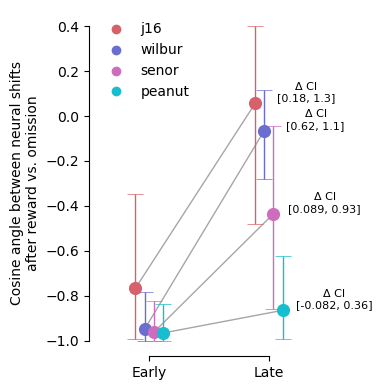

In [622]:
save_fig = True
if save_fig:
    figname = fig_dir+f"j16+wilbur+senor+peanut_initial_state_shift_cosine_postreward_vs_noreward_early_and_late_days_dotplot.pdf"

fig, ax, stats = plot_bootstrap_groups_by_animal(
    boots=cosine_angle_allrats_by_day,
    jitter=0.08,
    seed=0,
    connect_with_gray=True,
    annotate_delta_ci=True,
    figsize = (4,4),
    point_size = 90,
    fig_name=figname,
)

# stats